In [4]:
# ============================================================
# EEG COGNITIVE LOAD CLASSIFICATION - MASTER THESIS
# ============================================================
# Structure:
#   1. Imports & Setup
#   2. Data Loading
#   3. Windowing
#   4. Feature Extraction
#   5. Graph Builders
#   6. Model Definitions
#   7. Shared Training Functions
#   8. EXPERIMENT 1 - Channel Graph
#   9. EXPERIMENT 2 - Hetero Graph
#  10. EXPERIMENT 3 - LSTM Baseline
#  11. Comparison

# 1. IMPORT & SETUP

In [5]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install pyedflib torch_geometric

import os
import random
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pyedflib
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.signal import decimate, welch
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import RobustScaler

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GATConv, GCNConv, RGCNConv, global_mean_pool
from torch.nn import Linear
from torch.utils.data import WeightedRandomSampler, Dataset, DataLoader

from joblib import Parallel, delayed
from tqdm.notebook import tqdm

pd.set_option('display.max_columns', None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 98.1 MB/s eta 0:00:00
Using device: cuda


# 2. DATA LOADING

In [6]:
# ============================================================
# 2. DATA LOADING
# ============================================================

COMMON_CHANNELS = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8"]
FS = 250  # Hz

EDF_CHANNEL_MAP = {
    "Fp1": "EEG Fp1",
    "Fp2": "EEG Fp2",
    "F3":  "EEG F3",
    "F4":  "EEG F4",
    "F7":  "EEG F7",
    "F8":  "EEG F8",
    "Fz":  "EEG Fz"
}

TXT_CHANNELS      = ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "C2"]
TXT_TO_COMMON_IDX = [TXT_CHANNELS.index(ch) for ch in COMMON_CHANNELS]

In [7]:
def load_edf_dataset(base_path):
    samples  = []
    base_path = Path(base_path)

    for edf_file in base_path.glob("*.edf"):
        label = 0 if edf_file.stem.endswith("_1") else 1

        with pyedflib.EdfReader(str(edf_file)) as f:
            labels  = f.getSignalLabels()
            signals = []

            for ch in COMMON_CHANNELS:
                idx = labels.index(EDF_CHANNEL_MAP[ch])
                sig = f.readSignal(idx)
                sig = decimate(sig, 2, zero_phase=True)   # 500 → 250 Hz
                signals.append(sig)

            signals = np.vstack(signals)

        samples.append({
            "signals":  signals,
            "channels": COMMON_CHANNELS,
            "fs":       250,
            "label":    label,
            "source":   "EDF",
            "file":     edf_file.name
        })

    return samples

In [8]:
def load_txt_dataset(base_path):
    samples   = []
    base_path = Path(base_path)

    for txt_file in base_path.glob("*.txt"):
        name  = txt_file.stem.lower()
        label = 0 if name.startswith("natural") else 1

        df      = pd.read_csv(txt_file, sep=",", header=None, engine="python")
        eeg_all = df.iloc[:, 1:9].astype(float).values.T          # (8, T)
        eeg     = eeg_all[TXT_TO_COMMON_IDX, :]                    # (7, T)

        samples.append({
            "signals":  eeg,
            "channels": COMMON_CHANNELS,
            "fs":       FS,
            "label":    label,
            "source":   "TXT",
            "file":     txt_file.name
        })

    return samples

In [9]:
# --- Execute ---
edf_path = "/content/drive/MyDrive/Master Thesis/Datasets/dataset_1/eeg-during-mental-arithmetic-tasks-1.0.0"
txt_path = "/content/drive/MyDrive/Master Thesis/Datasets/dataset_2/Cognitive Load Assessment Through EEG A Dataset from Arithmetic and Stroop Tasks/raw_data/raw_data/Arithmetic_Data"

edf_samples = load_edf_dataset(edf_path)
txt_samples = load_txt_dataset(txt_path)
dataset     = edf_samples + txt_samples

print(f"Total recordings: {len(dataset)}")
print("Class counts:", Counter(s["label"] for s in dataset))

Total recordings: 132
Class counts: Counter({1: 81, 0: 51})


## Data visualisation

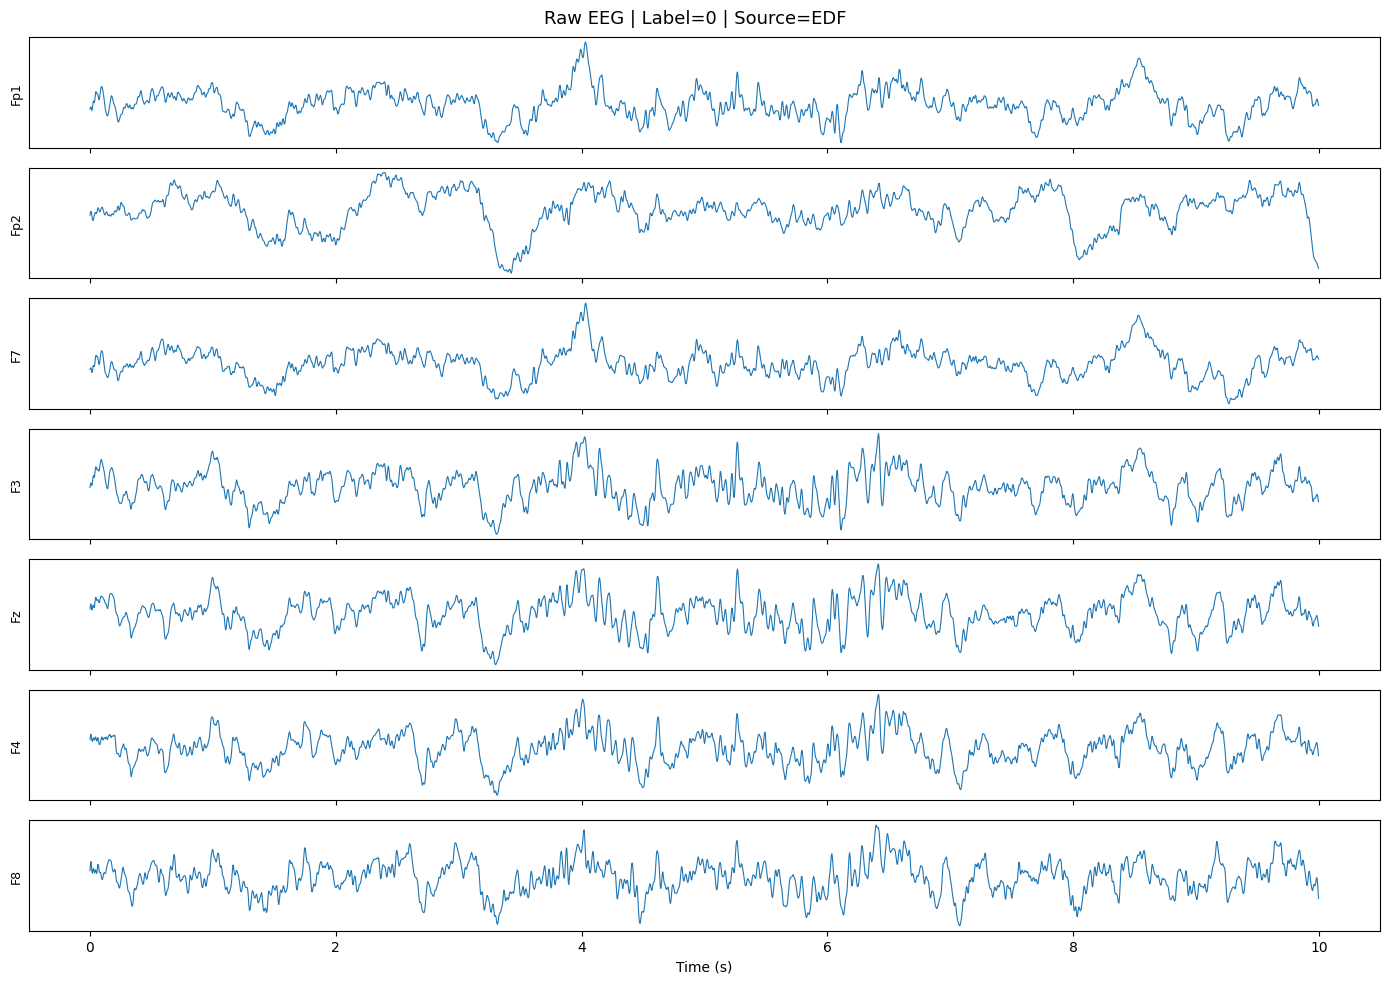

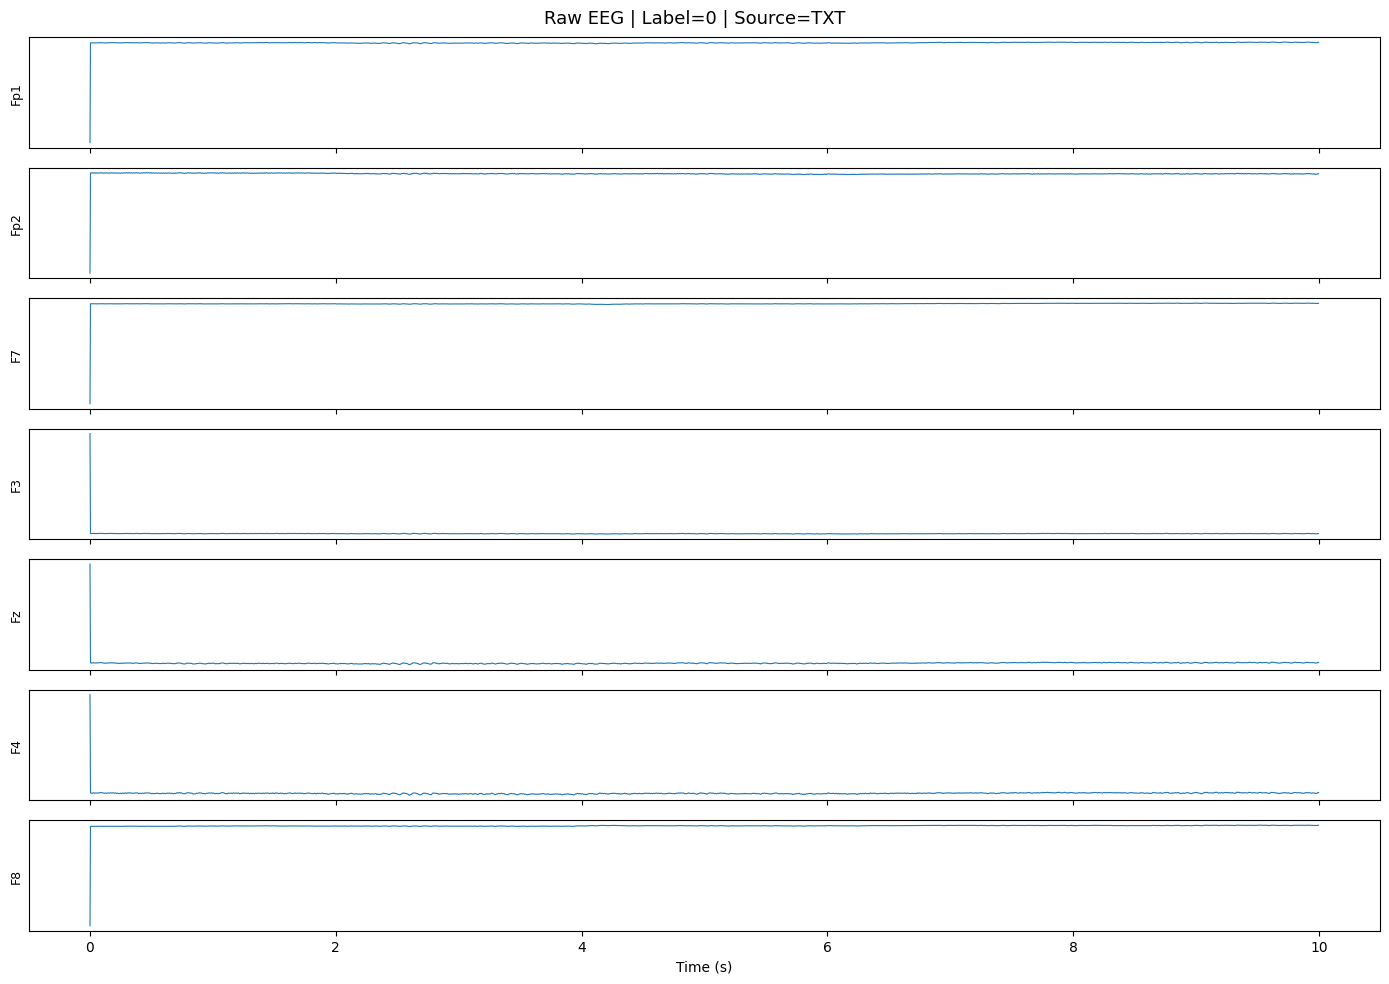

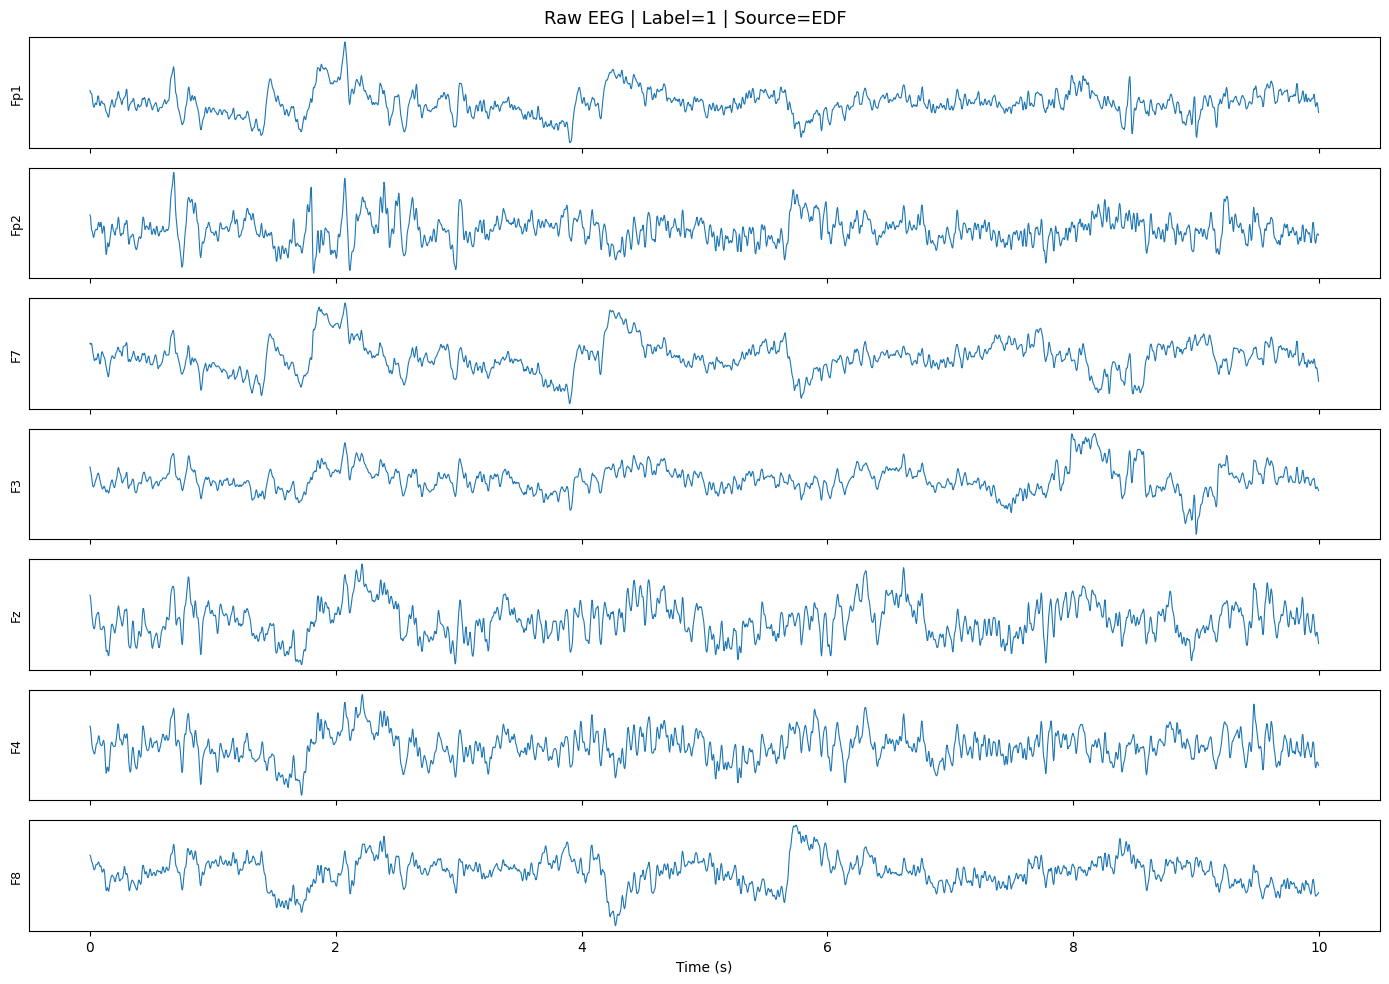

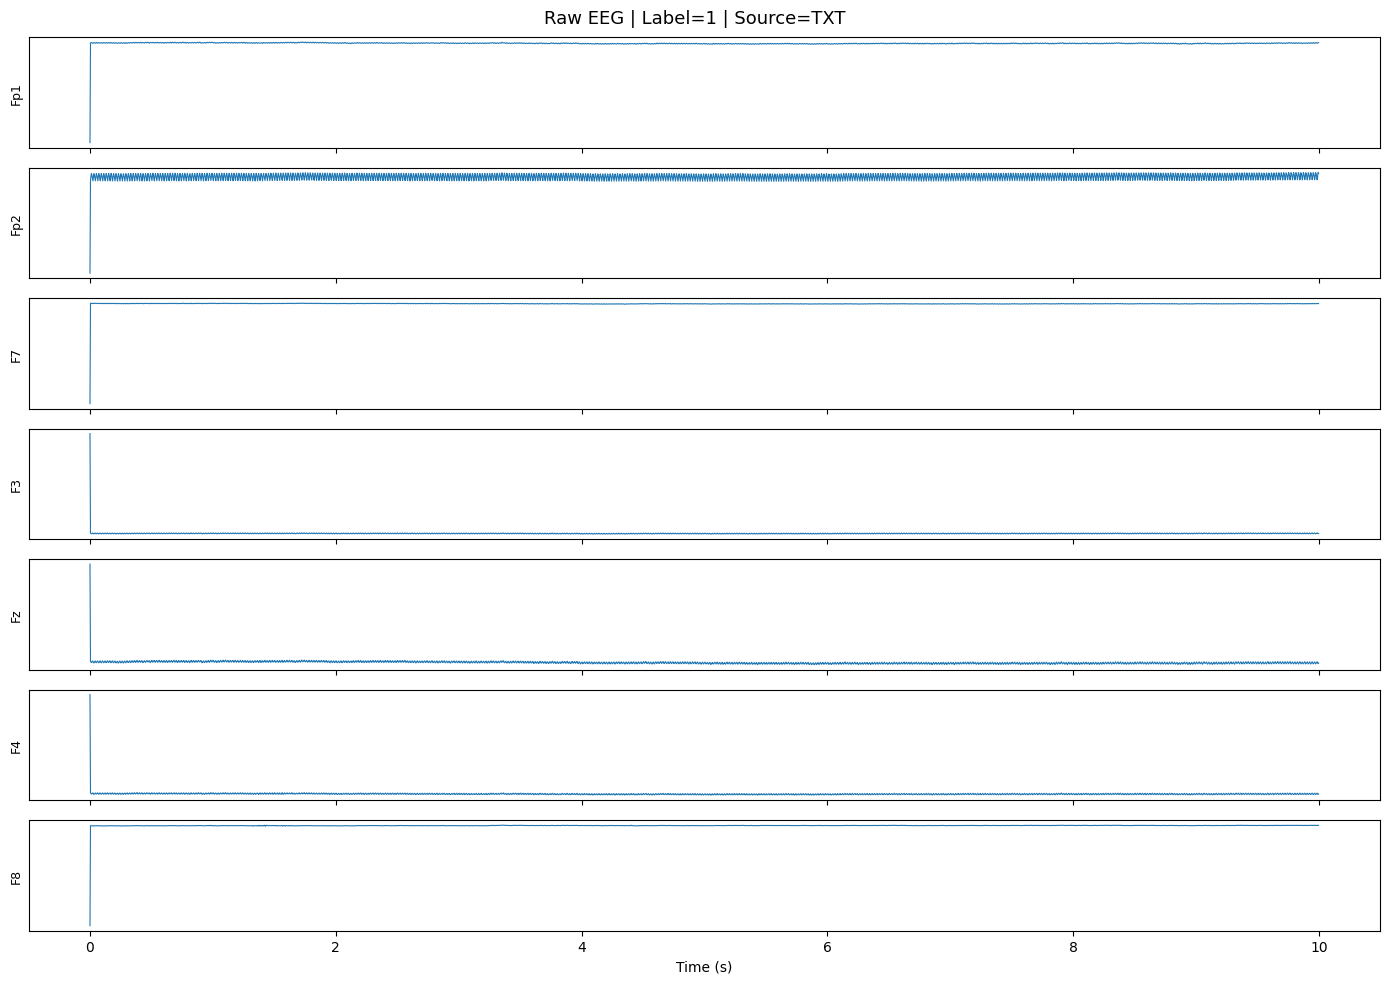

In [10]:
# ============================================================
# VIZ 1: Raw Signals per Recording
# ============================================================
def plot_raw_signal(sample, max_sec=10):
    sig = sample["signals"]           # (7, T)
    T   = int(max_sec * sample["fs"])
    t   = np.arange(T) / sample["fs"]

    fig, axes = plt.subplots(len(COMMON_CHANNELS), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Raw EEG | Label={sample['label']} | Source={sample['source']}", fontsize=13)

    for ch, ax in enumerate(axes):
        ax.plot(t, sig[ch, :T], linewidth=0.8)
        ax.set_ylabel(COMMON_CHANNELS[ch], fontsize=9)
        ax.set_yticks([])

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

# Plot one example from each class and source
for label in [0, 1]:
    sample = next(s for s in dataset if s["label"] == label and s["source"] == "EDF")
    plot_raw_signal(sample)
    sample = next(s for s in dataset if s["label"] == label and s["source"] == "TXT")
    plot_raw_signal(sample)

# 3. WINDOWING

In [11]:
# ============================================================
# 3. WINDOWING
# ============================================================

HYPER_SEC  = 30
HYPER_SIZE = HYPER_SEC * FS
HYPER_STEP = HYPER_SIZE                  # no overlap

SUB_SEC    = 1
SUB_SIZE   = SUB_SEC * FS
OVERLAP_SIZE = 0      # 0 means 0% Overlap and 0.1 means 10% Overlap
SUB_STEP   = int(SUB_SIZE * (1 - OVERLAP_SIZE)) # 0% overlap

In [12]:
def zscore_window(window, eps=1e-8):
    """Z-score per channel. window: (channels, T)"""
    mean = window.mean(axis=1, keepdims=True)
    std  = window.std(axis=1,  keepdims=True)
    return (window - mean) / (std + eps)


def window_signal(signal, window_size, step):
    """signal: (channels, T) → list of (channels, window_size)"""
    windows = []
    T = signal.shape[1]
    for start in range(0, T - window_size + 1, step):
        windows.append(signal[:, start:start + window_size])
    return windows

In [13]:
# --- Build hyper_df ---
hyper_windows, hyper_meta = [], []
hyper_id = 0

for sample_id, sample in enumerate(dataset):
    for hw in window_signal(sample["signals"], HYPER_SIZE, HYPER_STEP):
        hw_z = zscore_window(hw)
        hyper_windows.append(hw_z)
        hyper_meta.append({
            "hyper_id":  hyper_id,
            "sample_id": sample_id,
            "label":     sample["label"],
            "source":    sample["source"],
            "fs":        FS,
        })
        hyper_id += 1

hyper_df           = pd.DataFrame(hyper_meta)
hyper_df["signals"] = hyper_windows

print(f"Hyper-windows: {len(hyper_df)}")
print("Class counts:", Counter(hyper_df["label"]))

Hyper-windows: 447
Class counts: Counter({0: 262, 1: 185})


In [14]:
# --- Build sub_df ---
sub_windows, sub_meta = [], []
sub_id = 0

for _, row in hyper_df.iterrows():
    for sw_idx, sw in enumerate(window_signal(row["signals"], SUB_SIZE, SUB_STEP)):
        sub_windows.append(sw)
        sub_meta.append({
            "sub_id":   sub_id,
            "hyper_id": row["hyper_id"],
            "label":    row["label"],
            "source":   row["source"],
            "fs":       FS,
            "sub_idx":  sw_idx
        })
        sub_id += 1

sub_df           = pd.DataFrame(sub_meta)
sub_df["signals"] = sub_windows

print(f"Sub-windows: {len(sub_df)}")

# Sanity checks
assert hyper_df.iloc[0]["signals"].shape == (7, 7500)
assert sub_df.iloc[0]["signals"].shape   == (7, 250)
print("Windowing checks passed.")

Sub-windows: 13410
Windowing checks passed.


## Window visualisation

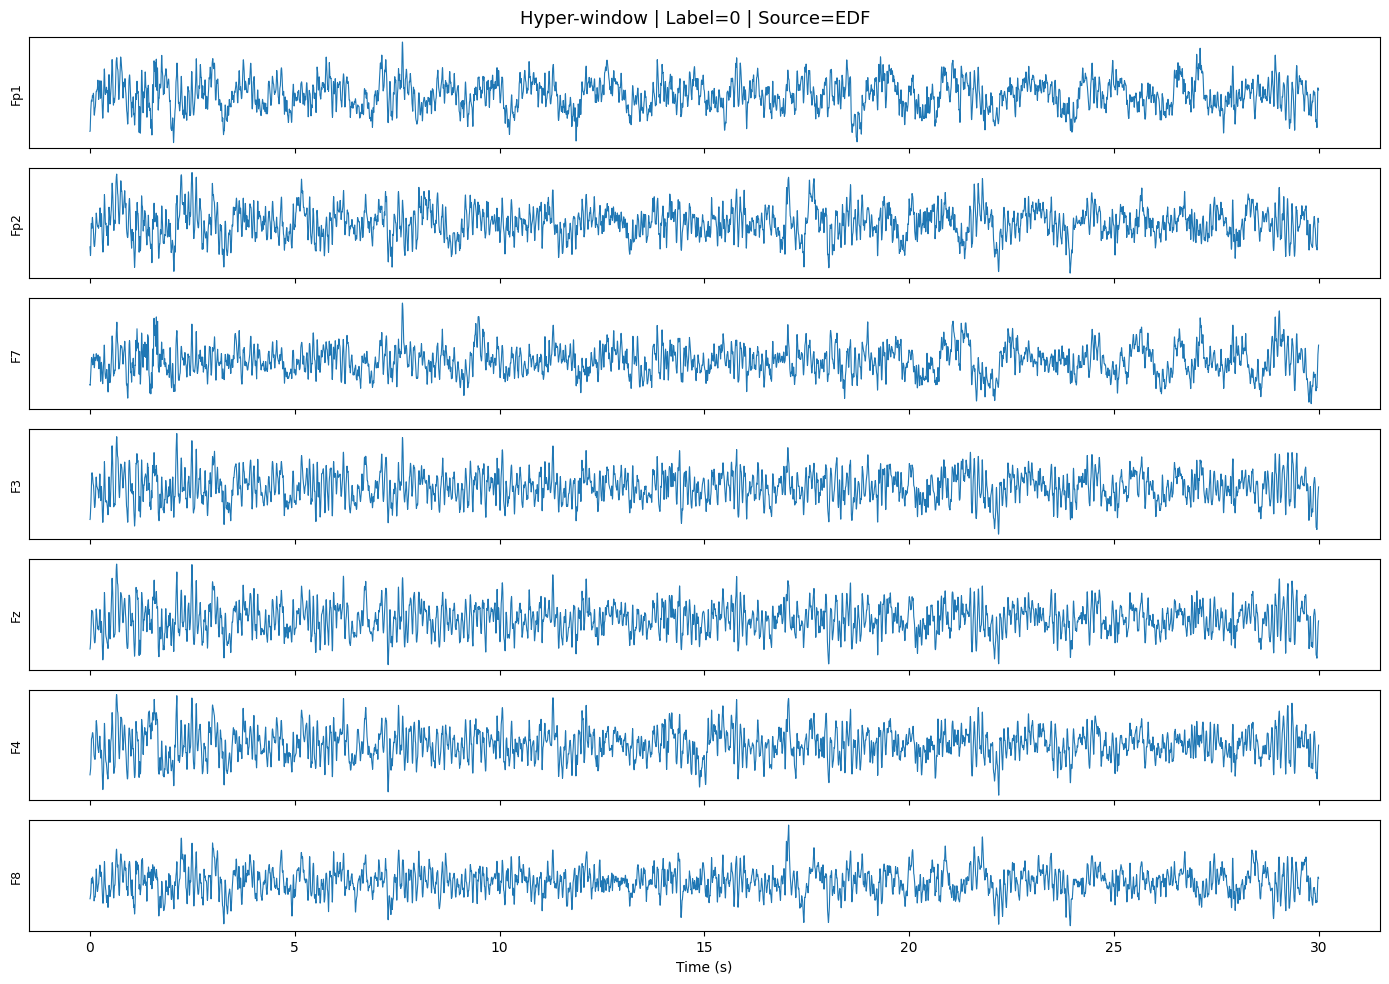

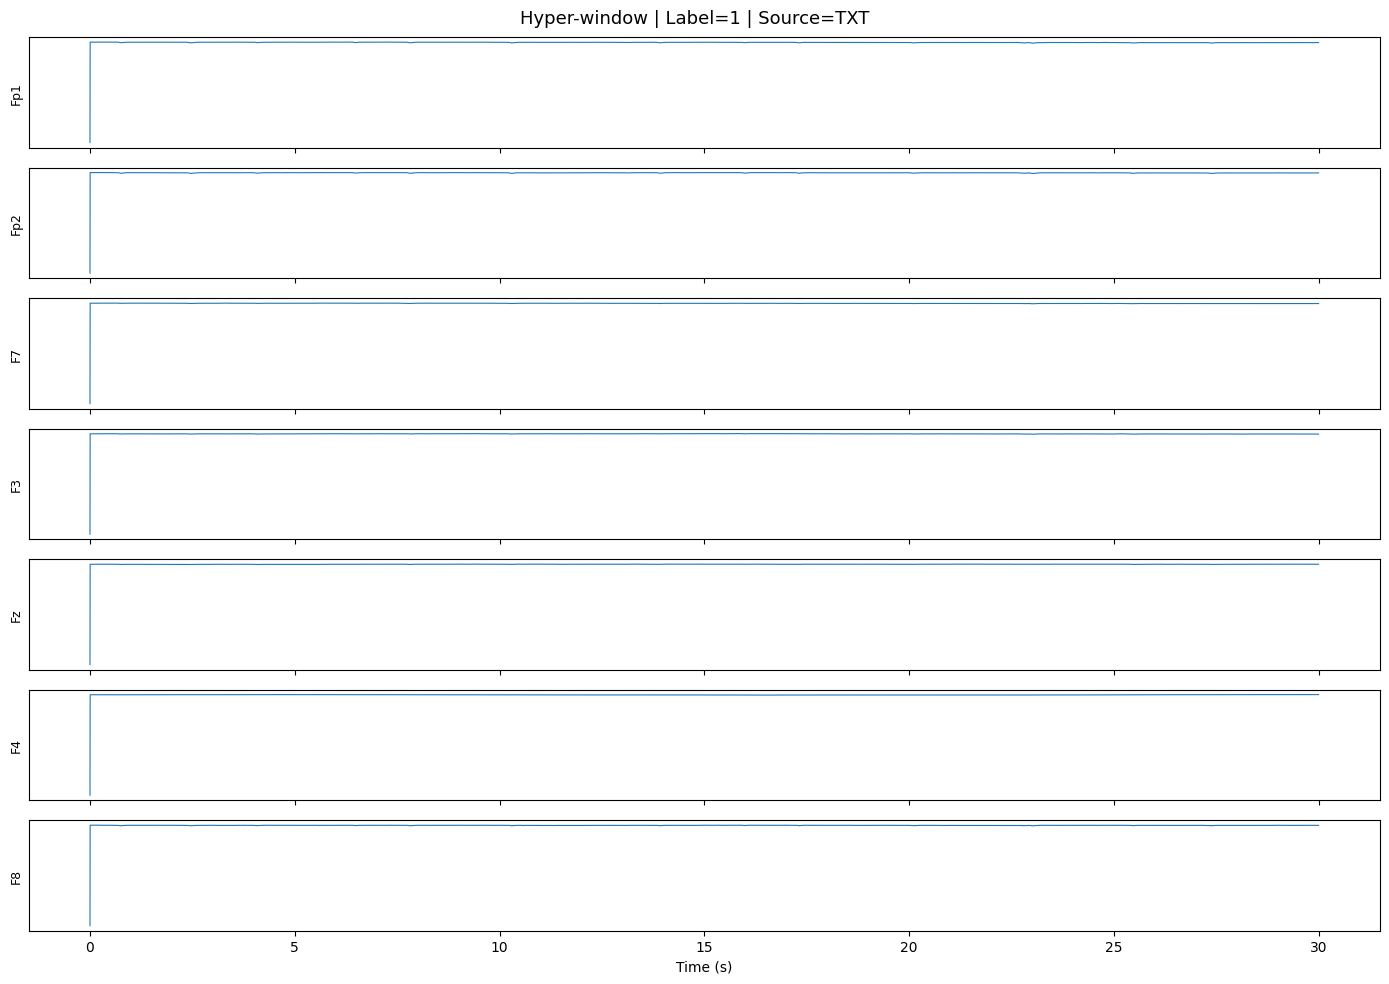

In [15]:
# ============================================================
# VIZ 2: Hyper-windows (one per class)
# ============================================================
def plot_hyper_window(row, max_sec=30):
    sig = row["signals"]              # (7, 7500)
    T   = int(max_sec * row["fs"])
    t   = np.arange(T) / row["fs"]

    fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Hyper-window | Label={row['label']} | Source={row['source']}", fontsize=13)

    for ch, ax in enumerate(axes):
        ax.plot(t, sig[ch, :T], linewidth=0.8)
        ax.set_ylabel(COMMON_CHANNELS[ch], fontsize=9)
        ax.set_yticks([])

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

for label in [0, 1]:
    row = hyper_df[hyper_df.label == label].sample(1).iloc[0]
    plot_hyper_window(row)

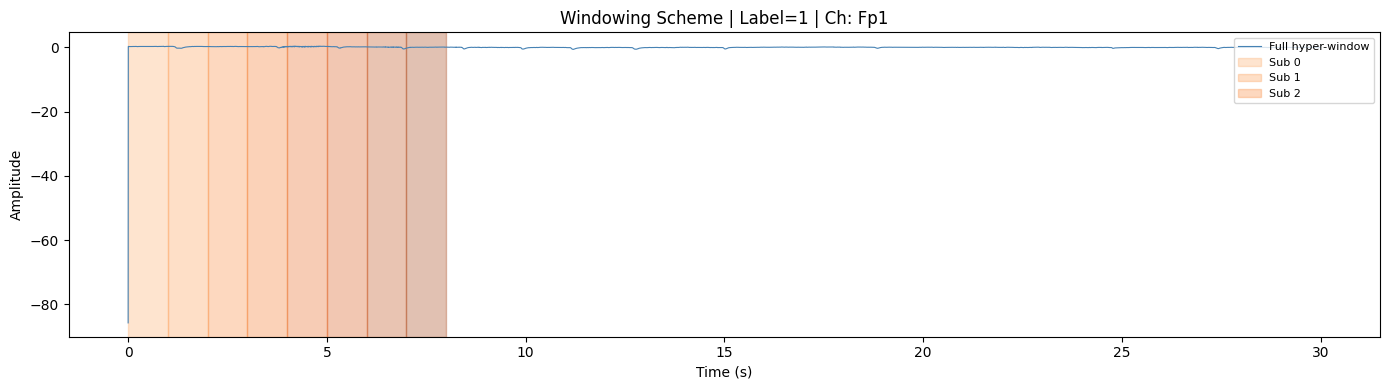

In [16]:
# ============================================================
# VIZ 3: Subwindows — overlaid on hyper-window to show windowing
# ============================================================
def plot_windowing_scheme(hyper_row, n_subs_to_show=8):
    sig = hyper_row["signals"][0]     # first channel only
    T   = len(sig)
    t   = np.arange(T) / hyper_row["fs"]

    plt.figure(figsize=(14, 4))
    plt.plot(t, sig, color="steelblue", linewidth=0.8, label="Full hyper-window")

    colors = plt.cm.Oranges(np.linspace(0.4, 0.9, n_subs_to_show))
    for idx in range(n_subs_to_show):
        start = idx * SUB_STEP
        end   = start + SUB_SIZE
        if end > T:
            break
        plt.axvspan(start / hyper_row["fs"], end / hyper_row["fs"],
                    alpha=0.3, color=colors[idx],
                    label=f"Sub {idx}" if idx < 3 else "")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Windowing Scheme | Label={hyper_row['label']} | Ch: {COMMON_CHANNELS[0]}")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

row = hyper_df.sample(1).iloc[0]
plot_windowing_scheme(row)

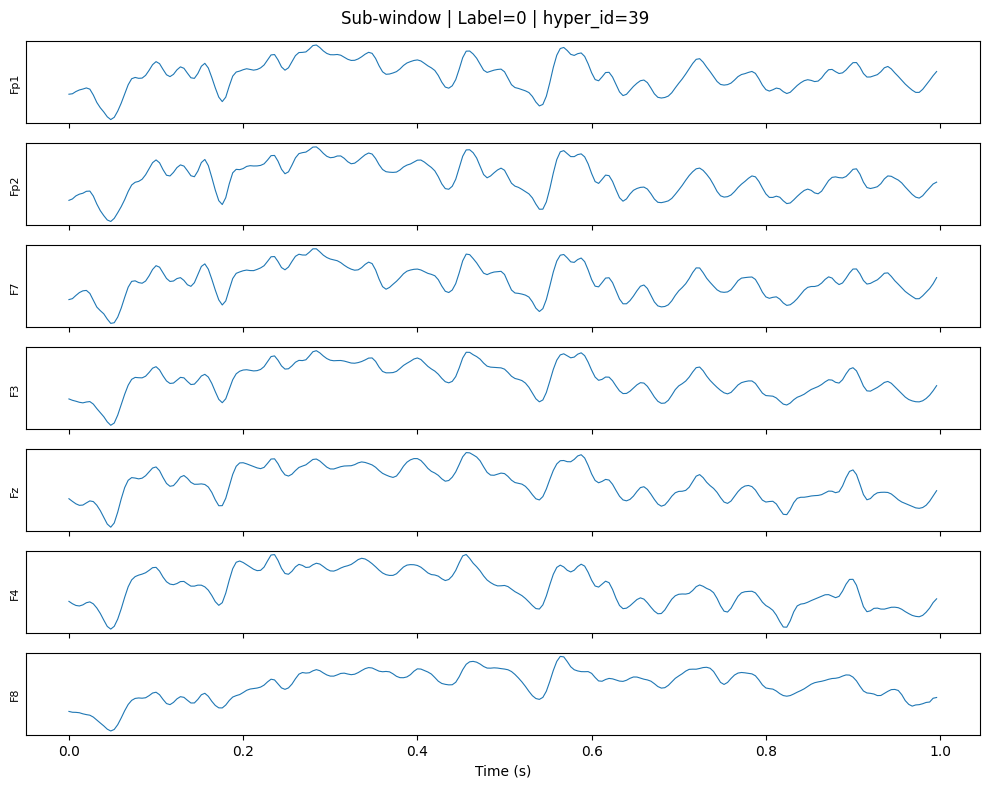

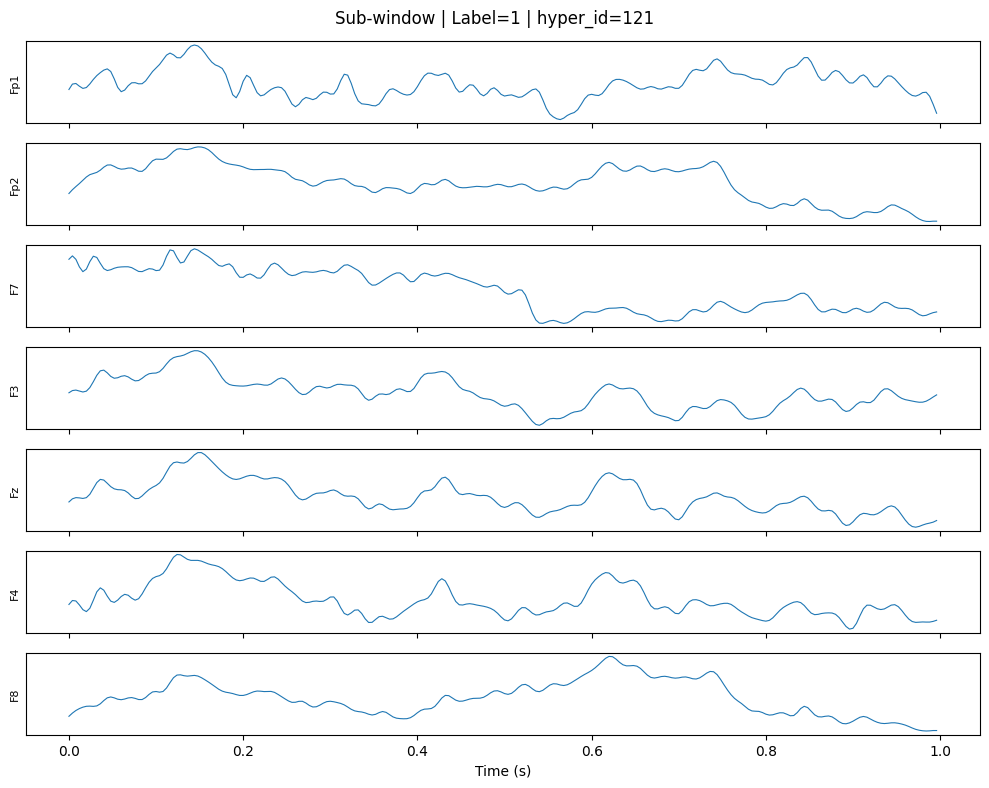

In [17]:
# ============================================================
# VIZ 4: Individual subwindow — all channels
# ============================================================
def plot_subwindow(row):
    sig = row["signals"]              # (7, 250)
    t   = np.arange(SUB_SIZE) / row["fs"]

    fig, axes = plt.subplots(7, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"Sub-window | Label={row['label']} | hyper_id={row['hyper_id']}", fontsize=12)

    for ch, ax in enumerate(axes):
        ax.plot(t, sig[ch], linewidth=0.8)
        ax.set_ylabel(COMMON_CHANNELS[ch], fontsize=8)
        ax.set_yticks([])

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

for label in [0, 1]:
    row = sub_df[sub_df.label == label].sample(1).iloc[0]
    plot_subwindow(row)

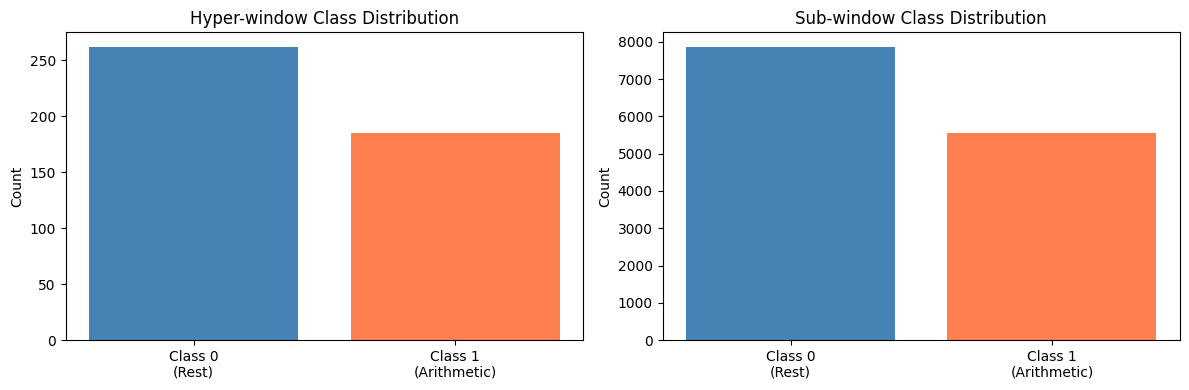

In [18]:
# ============================================================
# VIZ 5: Class distribution bar chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hyper-window level
counts_hw = Counter(hyper_df["label"])
axes[0].bar(["Class 0\n(Rest)", "Class 1\n(Arithmetic)"],
            [counts_hw[0], counts_hw[1]], color=["steelblue", "coral"])
axes[0].set_title("Hyper-window Class Distribution")
axes[0].set_ylabel("Count")

# Sub-window level
counts_sw = Counter(sub_df["label"])
axes[1].bar(["Class 0\n(Rest)", "Class 1\n(Arithmetic)"],
            [counts_sw[0], counts_sw[1]], color=["steelblue", "coral"])
axes[1].set_title("Sub-window Class Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# 4. FEATURE EXTRACTION

In [19]:
# ============================================================
# 4. FEATURE EXTRACTION
# ============================================================

def safe_bandpower(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs <= fmax)
    if idx.sum() == 0:
        return 0.0
    return float(np.trapezoid(psd[idx], freqs[idx]))


def extract_node_features(subwindow, fs=250):
    """
    subwindow: (channels, time)
    Returns: (channels * 19,) feature vector
    """
    features = []

    for ch in range(subwindow.shape[0]):
        sig = subwindow[ch]

        if sig.std() < 1e-10:          # flat signal guard
            features.extend([0.0] * 19)
            continue

        freqs, psd = welch(sig, fs=fs, nperseg=min(len(sig), fs * 2))

        # Time domain
        features.extend([
            float(sig.mean()),
            float(sig.std()),
            float(np.sqrt(np.mean(sig ** 2))),   # RMS
            float(sig.max() - sig.min()),         # peak-to-peak
            float(skew(sig)),
            float(kurtosis(sig)),
        ])

        # Frequency bands
        total = max(safe_bandpower(freqs, psd, 0.5, 40), 1e-8)
        delta = safe_bandpower(freqs, psd, 0.5, 4)
        theta = safe_bandpower(freqs, psd, 4,   8)
        alpha = safe_bandpower(freqs, psd, 8,  13)
        beta  = safe_bandpower(freqs, psd, 13, 30)
        gamma = safe_bandpower(freqs, psd, 30, 40)

        features.extend([
            delta, theta, alpha, beta, gamma,
            delta / total,
            theta / total,
            alpha / total,
            beta  / total,
            gamma / total,
            theta / max(alpha, 1e-8),             # theta/alpha ratio
            (theta + alpha) / max(beta, 1e-8),    # engagement index
        ])

        # Spectral entropy
        psd_norm = psd / (psd.sum() + 1e-8)
        features.append(float(-np.sum(psd_norm * np.log2(psd_norm + 1e-8))))

    return np.array(features, dtype=np.float32)

In [20]:
# --- Execute feature extraction ---

In [21]:
raw_features = Parallel(n_jobs=-1)(
    delayed(extract_node_features)(sig)
    for sig in tqdm(sub_df["signals"], total=len(sub_df), desc="Extracting features")
)
sub_df["node_features"] = raw_features

# Verify no NaNs
all_feats = np.vstack(sub_df["node_features"].values)
assert np.isnan(all_feats).sum() == 0, "NaNs found in features!"
print(f"Feature shape per subwindow: {all_feats.shape[1]}")   # should be 133

# Scale features
scaler            = RobustScaler()
all_feats_scaled  = scaler.fit_transform(all_feats)
sub_df["node_features"] = list(all_feats_scaled)

print("Feature extraction and scaling complete.")

Extracting features:   0%|          | 0/13410 [00:00<?, ?it/s]

Feature shape per subwindow: 133
Feature extraction and scaling complete.


## Feature visualisation:

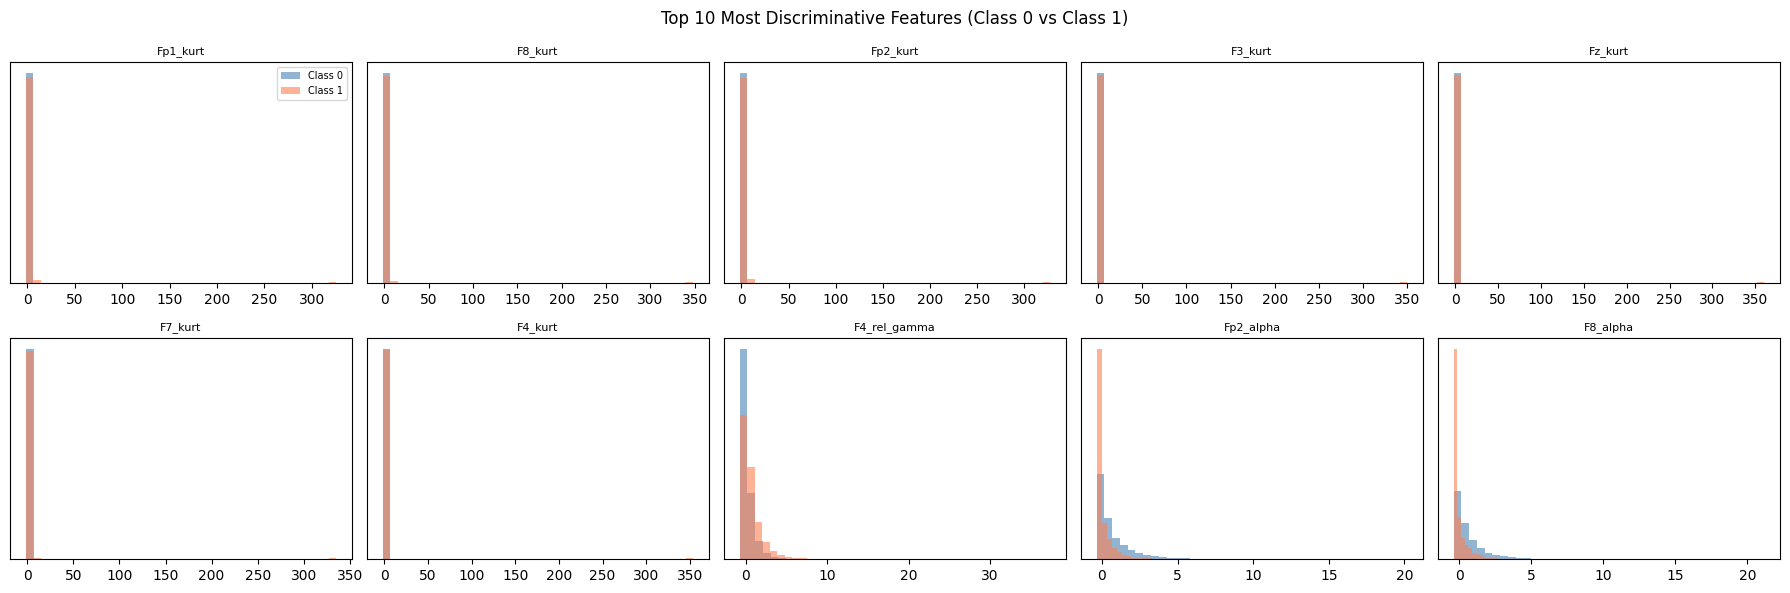

In [22]:
# ============================================================
# VIZ 6: Feature distributions by class
# ============================================================
feats_0 = np.vstack(sub_df[sub_df.label == 0]["node_features"].values)
feats_1 = np.vstack(sub_df[sub_df.label == 1]["node_features"].values)

FEATURE_NAMES = []
for ch in COMMON_CHANNELS:
    for feat in ["mean", "std", "rms", "p2p", "skew", "kurt",
                 "delta", "theta", "alpha", "beta", "gamma",
                 "rel_delta", "rel_theta", "rel_alpha", "rel_beta", "rel_gamma",
                 "theta/alpha", "engagement", "spec_entropy"]:
        FEATURE_NAMES.append(f"{ch}_{feat}")

# Plot top-10 most discriminative features by mean difference
diffs = np.abs(feats_0.mean(axis=0) - feats_1.mean(axis=0))
top10_idx = np.argsort(diffs)[-10:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for plot_i, feat_i in enumerate(top10_idx):
    ax = axes[plot_i]
    ax.hist(feats_0[:, feat_i], bins=40, alpha=0.6, color="steelblue", label="Class 0", density=True)
    ax.hist(feats_1[:, feat_i], bins=40, alpha=0.6, color="coral",     label="Class 1", density=True)
    ax.set_title(FEATURE_NAMES[feat_i], fontsize=8)
    ax.set_yticks([])
    if plot_i == 0:
        ax.legend(fontsize=7)

plt.suptitle("Top 10 Most Discriminative Features (Class 0 vs Class 1)", fontsize=12)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


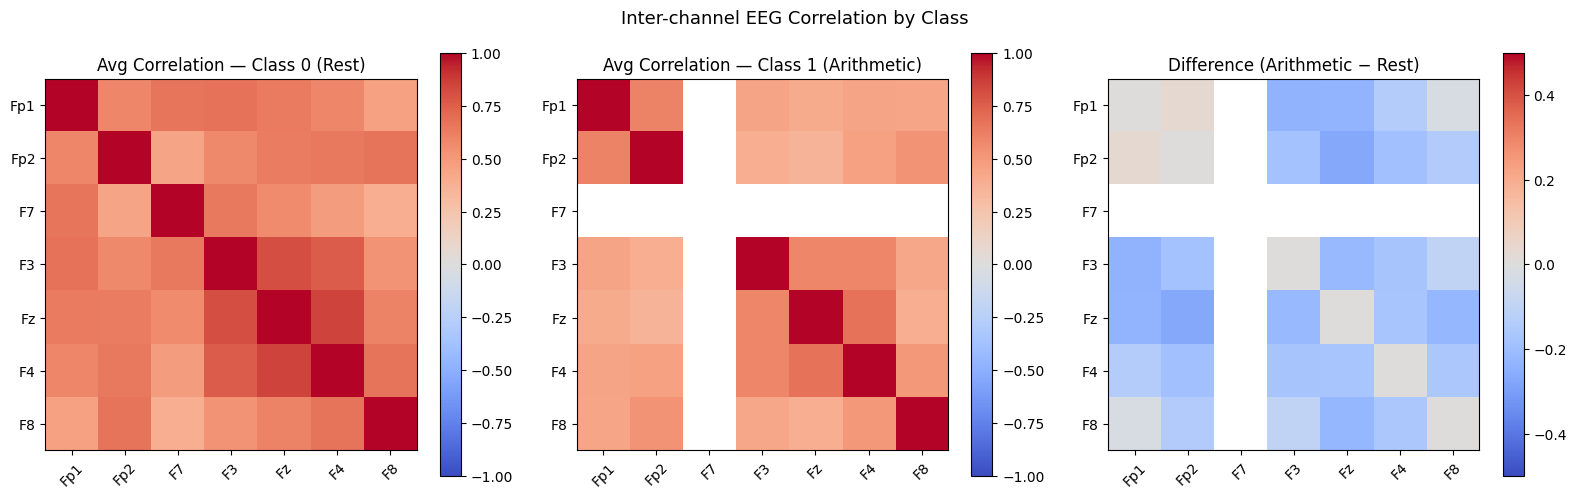

In [23]:
# ============================================================
# VIZ 7: Inter-channel correlation heatmap (avg per class)
# ============================================================
def avg_corr_matrix(df, label):
    corrs = []
    for sig in df[df.label == label]["signals"].values:
        corrs.append(np.corrcoef(sig))
    return np.mean(corrs, axis=0)

corr0 = avg_corr_matrix(hyper_df, 0)
corr1 = avg_corr_matrix(hyper_df, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(corr0, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Avg Correlation — Class 0 (Rest)")
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(COMMON_CHANNELS, rotation=45)
axes[0].set_yticks(range(7)); axes[0].set_yticklabels(COMMON_CHANNELS)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(corr1, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Avg Correlation — Class 1 (Arithmetic)")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(COMMON_CHANNELS, rotation=45)
axes[1].set_yticks(range(7)); axes[1].set_yticklabels(COMMON_CHANNELS)
plt.colorbar(im1, ax=axes[1])

diff_corr = corr1 - corr0
im2 = axes[2].imshow(diff_corr, vmin=-0.5, vmax=0.5, cmap="coolwarm")
axes[2].set_title("Difference (Arithmetic − Rest)")
axes[2].set_xticks(range(7)); axes[2].set_xticklabels(COMMON_CHANNELS, rotation=45)
axes[2].set_yticks(range(7)); axes[2].set_yticklabels(COMMON_CHANNELS)
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Inter-channel EEG Correlation by Class", fontsize=13)
plt.tight_layout()
plt.show()

# 5. SHARED GRAPH UTILITIES

In [24]:
# ============================================================
# 5. SHARED GRAPH UTILITIES
# ============================================================

def graph_dict_to_pyg(graph):
    data = Data(
        x           = torch.tensor(graph["x"],          dtype=torch.float),
        edge_index  = torch.tensor(graph["edge_index"], dtype=torch.long),
        edge_weight = torch.tensor(graph["edge_weight"],dtype=torch.float),
        y           = torch.tensor([graph["label"]],    dtype=torch.long)
    )
    if "edge_type" in graph:
        data.edge_type = torch.tensor(graph["edge_type"], dtype=torch.long)
    return data


def stratified_split(graphs, train_ratio=0.7, val_ratio=0.15, seed=42):
    assert train_ratio + val_ratio < 1.0
    random.seed(seed)

    by_class = defaultdict(list)
    for g in graphs:
        by_class[g.y.item()].append(g)

    train, val, test = [], [], []
    for cls_graphs in by_class.values():
        random.shuffle(cls_graphs)
        n       = len(cls_graphs)
        n_train = int(train_ratio * n)
        n_val   = int(val_ratio   * n)
        train  += cls_graphs[:n_train]
        val    += cls_graphs[n_train:n_train + n_val]
        test   += cls_graphs[n_train + n_val:]

    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)
    return train, val, test


def make_weighted_loader(graphs, batch_size=16):
    """GeoDataLoader with weighted sampling for class balance."""
    labels  = [g.y.item() for g in graphs]
    counts  = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    return GeoDataLoader(graphs, batch_size=batch_size, sampler=sampler)

# 6. GRAPH BUILDERS

In [25]:
# ============================================================
# 6. GRAPH BUILDERS
# ============================================================

## 6A. Channel Graph

In [26]:
# ------ 6A. Channel Graph ------

def build_channel_graph(hyper_window, label, fs=250):
    n_ch       = hyper_window.shape[0]
    node_feats = []

    for ch in range(n_ch):
        sig   = hyper_window[ch]
        feats = extract_node_features(sig[np.newaxis, :], fs=fs)
        node_feats.append(feats)

    node_feats = np.vstack(node_feats)  # (7, 19) — no scaler here

    corr = np.corrcoef(hyper_window)
    edge_index, edge_weight = [], []

    for i in range(n_ch):
        for j in range(n_ch):
            if i != j and abs(corr[i, j]) > 0.3:
                edge_index.append([i, j])
                edge_weight.append(float(corr[i, j]))

    if len(edge_index) == 0:
        for i in range(n_ch - 1):
            edge_index.append([i, i + 1])
            edge_weight.append(0.1)

    return {
        "x":           node_feats,
        "edge_index":  np.array(edge_index).T,
        "edge_weight": np.array(edge_weight),
        "label":       label
    }


# --- Execute: build raw graphs first ---
channel_graphs_raw = []
for _, row in tqdm(hyper_df.iterrows(), total=len(hyper_df), desc="Building channel graphs"):
    g = build_channel_graph(row["signals"], row["label"])
    channel_graphs_raw.append(g)

# --- Fit a separate scaler on channel-level features ---
ch_all_feats  = np.vstack([g["x"] for g in channel_graphs_raw])
ch_scaler     = RobustScaler()
ch_all_scaled = ch_scaler.fit_transform(ch_all_feats)

# Put scaled features back
n_ch = channel_graphs_raw[0]["x"].shape[0]
for i, g in enumerate(channel_graphs_raw):
    g["x"] = ch_all_scaled[i * n_ch:(i + 1) * n_ch]

# --- Convert to PyG ---
channel_graphs = [graph_dict_to_pyg(g) for g in channel_graphs_raw]

print(f"Channel graphs: {len(channel_graphs)}")
print(f"  Nodes per graph : {channel_graphs[0].x.size(0)}")   # 7
print(f"  Features / node : {channel_graphs[0].x.size(1)}")   # 19
print(f"  Edges per graph : {channel_graphs[0].edge_index.size(1)}")

Building channel graphs:   0%|          | 0/447 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Channel graphs: 447
  Nodes per graph : 7
  Features / node : 19
  Edges per graph : 42


### Channel Graph Visualisation:

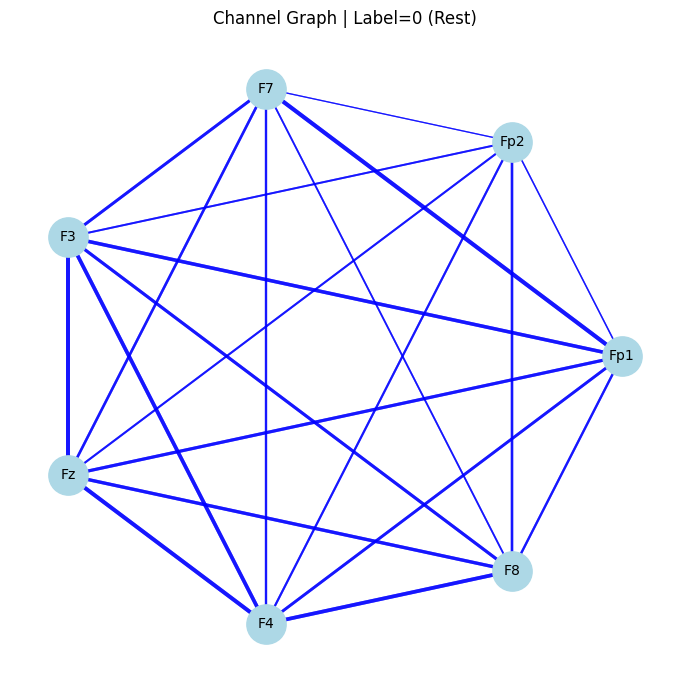

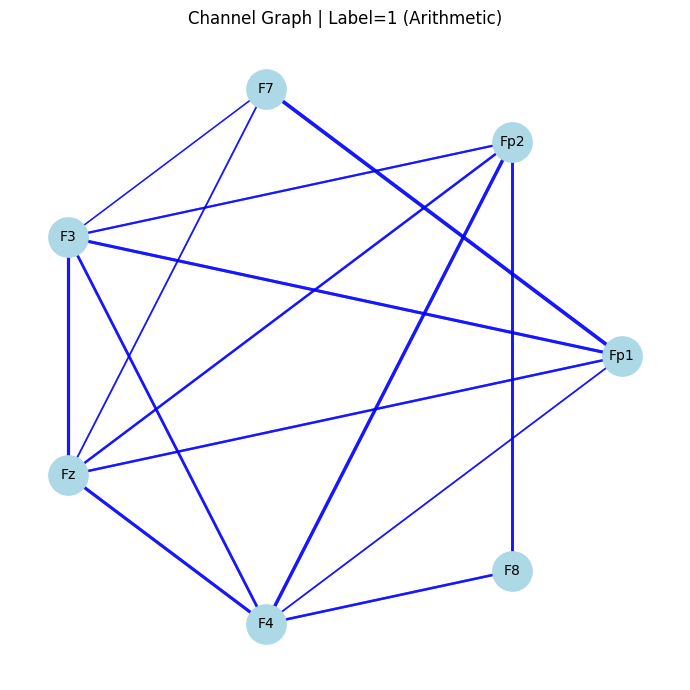

In [27]:
# ============================================================
# VIZ 8: Channel graph visualisation
# ============================================================
import networkx as nx
from torch_geometric.utils import to_networkx

def plot_channel_graph(pyg_data, title=""):
    G   = to_networkx(pyg_data, edge_attrs=["edge_weight"])
    pos = {i: (np.cos(2 * np.pi * i / 7), np.sin(2 * np.pi * i / 7))
           for i in range(7)}   # circular layout matching electrode positions

    edge_weights = [G[u][v]["edge_weight"] for u, v in G.edges()]
    edge_colors  = ["red" if w < 0 else "blue" for w in edge_weights]
    edge_widths  = [abs(w) * 3 for w in edge_weights]

    plt.figure(figsize=(7, 7))
    nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightblue")
    nx.draw_networkx_labels(G, pos,
                            labels={i: COMMON_CHANNELS[i] for i in range(7)},
                            font_size=10)
    nx.draw_networkx_edges(G, pos,
                           edge_color=edge_colors,
                           width=edge_widths,
                           alpha=0.7,
                           arrows=False)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# One graph per class
for label in [0, 1]:
    idx  = next(i for i, g in enumerate(channel_graphs) if g.y.item() == label)
    plot_channel_graph(channel_graphs[idx],
                       title=f"Channel Graph | Label={label} ({'Rest' if label==0 else 'Arithmetic'})")

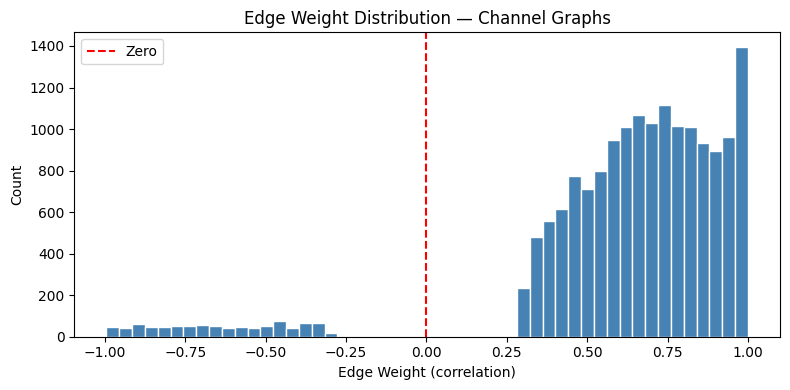

In [28]:
# ============================================================
# VIZ 9: Edge weight distribution — channel graphs
# ============================================================
all_edge_weights = np.concatenate([g.edge_weight.numpy() for g in channel_graphs])

plt.figure(figsize=(8, 4))
plt.hist(all_edge_weights, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", label="Zero")
plt.xlabel("Edge Weight (correlation)")
plt.ylabel("Count")
plt.title("Edge Weight Distribution — Channel Graphs")
plt.legend()
plt.tight_layout()
plt.show()

## 6B. Hetero Graph

In [29]:
def cosine_sim(a, b, eps=1e-8):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + eps))

def build_hetero_graph(hyper_window, label, fs=250,
                       corr_threshold=0.3, sim_threshold=0.3, k=3):
    n_ch = hyper_window.shape[0]

    sws_per_ch = []
    for ch in range(n_ch):
        sig = hyper_window[ch:ch + 1, :]
        sws_per_ch.append(window_signal(sig, SUB_SIZE, SUB_STEP))

    n_subs  = len(sws_per_ch[0])

    def node_id(ch, t):
        return ch * n_subs + t

    # Node features — NO scaler here
    node_feats = []
    for ch in range(n_ch):
        for sw in sws_per_ch[ch]:
            feats = extract_node_features(sw, fs=fs)
            node_feats.append(feats)
    node_feats = np.vstack(node_feats)  # (n_nodes, 19)

    edge_index, edge_weight, edge_type = [], [], []

    # Type 0: Temporal
    for ch in range(n_ch):
        for t in range(n_subs - 1):
            i, j = node_id(ch, t), node_id(ch, t + 1)
            edge_index += [[i, j], [j, i]]
            edge_weight += [1.0, 1.0]
            edge_type   += [0, 0]

    # Type 1: Channel
    corr = np.corrcoef(hyper_window)
    for t in range(n_subs):
        for ch1 in range(n_ch):
            for ch2 in range(n_ch):
                if ch1 != ch2 and abs(corr[ch1, ch2]) > corr_threshold:
                    edge_index.append([node_id(ch1, t), node_id(ch2, t)])
                    edge_weight.append(float(corr[ch1, ch2]))
                    edge_type.append(1)

    # Type 2: Subwindow similarity
    for ch in range(n_ch):
        sws = sws_per_ch[ch]
        sim = np.zeros((n_subs, n_subs))
        for t1 in range(n_subs):
            for t2 in range(t1 + 1, n_subs):
                s = cosine_sim(sws[t1][0], sws[t2][0])
                sim[t1, t2] = sim[t2, t1] = s

        for t1 in range(n_subs):
            exclude    = {t1, t1 - 1, t1 + 1}
            candidates = sorted(
                [(sim[t1, t2], t2) for t2 in range(n_subs) if t2 not in exclude],
                reverse=True
            )
            for sim_val, t2 in candidates[:k]:
                if sim_val > sim_threshold:
                    edge_index.append([node_id(ch, t1), node_id(ch, t2)])
                    edge_weight.append(float(sim_val))
                    edge_type.append(2)

    return {
        "x":           node_feats,
        "edge_index":  np.array(edge_index).T,
        "edge_weight": np.array(edge_weight, dtype=np.float32),
        "edge_type":   np.array(edge_type,   dtype=np.int64),
        "label":       label
    }


# --- Execute: build raw, then scale ---
hetero_graphs_raw = []
for _, row in tqdm(hyper_df.iterrows(), total=len(hyper_df), desc="Building hetero graphs"):
    hetero_graphs_raw.append(build_hetero_graph(row["signals"], row["label"]))

# Fit separate scaler on hetero node features
ht_all_feats  = np.vstack([g["x"] for g in hetero_graphs_raw])
ht_scaler     = RobustScaler()
ht_all_scaled = ht_scaler.fit_transform(ht_all_feats)

# Put scaled features back
for i, g in enumerate(hetero_graphs_raw):
    n = g["x"].shape[0]
    start = sum(hetero_graphs_raw[j]["x"].shape[0] for j in range(i))
    g["x"] = ht_all_scaled[start:start + n]

# Convert to PyG
hetero_graphs = [graph_dict_to_pyg(g) for g in hetero_graphs_raw]

print(f"Hetero graphs: {len(hetero_graphs)}")
print(f"  Nodes per graph : {hetero_graphs[0].x.size(0)}")
print(f"  Features / node : {hetero_graphs[0].x.size(1)}")
print(f"  Edges per graph : {hetero_graphs[0].edge_index.size(1)}")

Building hetero graphs:   0%|          | 0/447 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Hetero graphs: 447
  Nodes per graph : 210
  Features / node : 19
  Edges per graph : 2184


### Hetero Graph Visualisation:

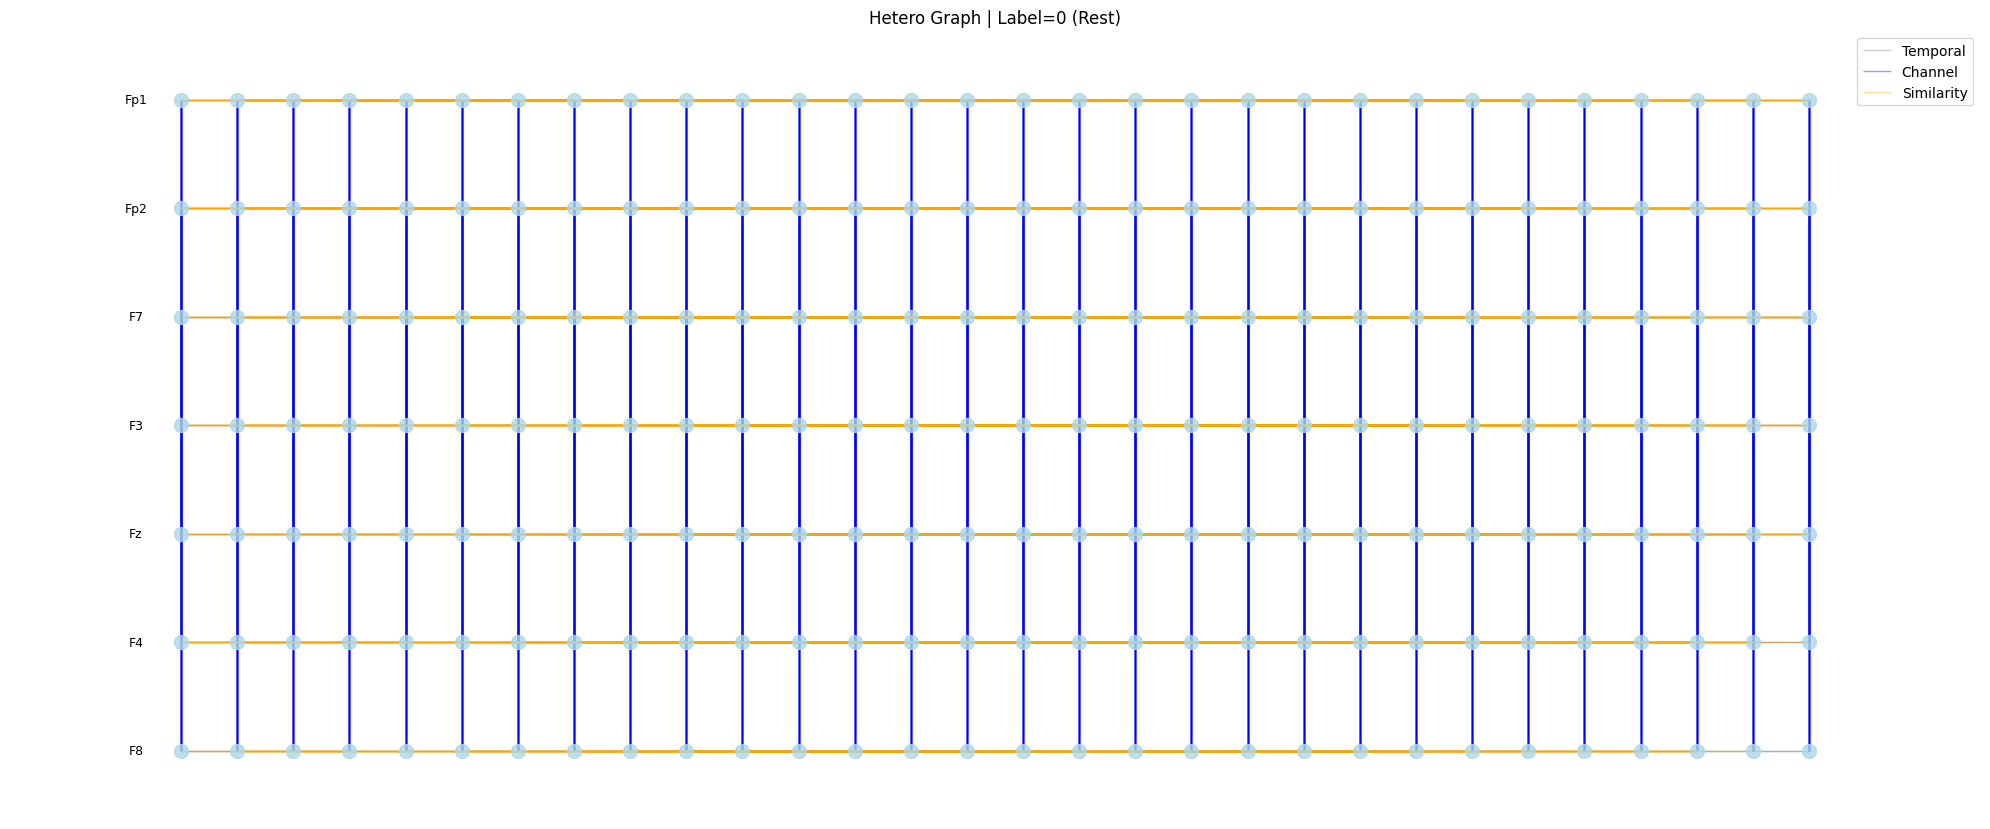

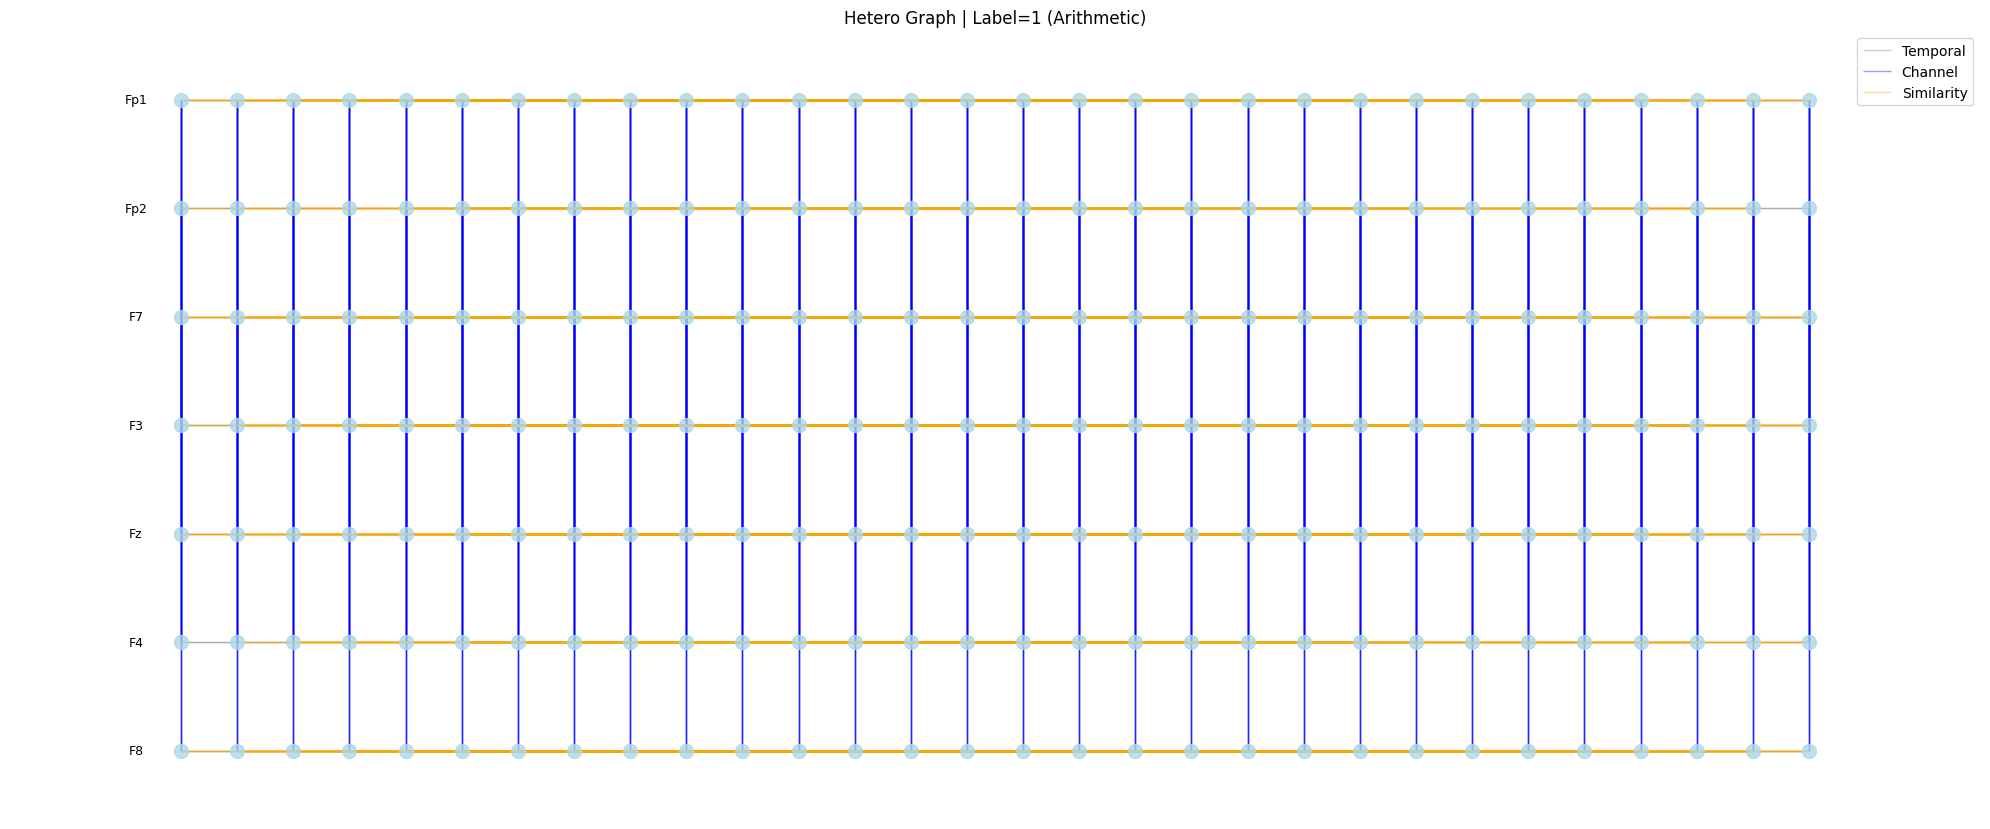

In [30]:
# ============================================================
# VIZ 10: Hetero graph visualisation
# ============================================================
def plot_hetero_graph(pyg_data, n_ch=7, title=""):
    n_nodes = pyg_data.x.size(0)
    n_subs  = n_nodes // n_ch

    G          = nx.DiGraph()
    edge_index = pyg_data.edge_index.numpy()
    edge_types = pyg_data.edge_type.numpy()

    G.add_nodes_from(range(n_nodes))

    type_colors = {0: "gray", 1: "blue", 2: "orange"}
    type_labels = {0: "Temporal", 1: "Channel", 2: "Similarity"}

    # Layout: channels as rows, subwindows as columns
    pos = {}
    for ch in range(n_ch):
        for t in range(n_subs):
            node = ch * n_subs + t
            pos[node] = (t, -ch)

    plt.figure(figsize=(min(n_subs * 1.2, 20), n_ch * 1.2))

    nx.draw_networkx_nodes(G, pos, node_size=100, node_color="lightblue", alpha=0.8)

    for etype, color in type_colors.items():
        mask  = edge_types == etype
        edges = edge_index[:, mask].T.tolist()
        if edges:
            nx.draw_networkx_edges(G, pos, edgelist=edges,
                                   edge_color=color, alpha=0.4,
                                   width=1.0, arrows=False,
                                   label=type_labels[etype])

    # Label only channel names on left side
    label_pos  = {ch * n_subs: (-0.8, -ch) for ch in range(n_ch)}
    label_dict = {ch * n_subs: COMMON_CHANNELS[ch] for ch in range(n_ch)}
    nx.draw_networkx_labels(G, label_pos, labels=label_dict, font_size=9)

    plt.legend(loc="upper right")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

for label in [0, 1]:
    idx = next(i for i, g in enumerate(hetero_graphs) if g.y.item() == label)
    plot_hetero_graph(hetero_graphs[idx],
                      title=f"Hetero Graph | Label={label} ({'Rest' if label==0 else 'Arithmetic'})")

# 7. MODEL DEFINITIONS

In [31]:
# ============================================================
# 7. MODEL DEFINITIONS
# ============================================================

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn1   = nn.BatchNorm1d(hidden_channels)
        self.bn2   = nn.BatchNorm1d(hidden_channels)
        self.lin   = nn.Sequential(
            Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(32, 2)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.lin(x)

In [32]:
class GATClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=4, dropout=0.4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels,
                            heads=1, concat=False, dropout=dropout)
        self.bn1  = nn.BatchNorm1d(hidden_channels * heads)
        self.bn2  = nn.BatchNorm1d(hidden_channels)
        self.lin  = nn.Sequential(
            Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(32, 2)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.bn1(self.gat1(x, edge_index)))
        x = F.elu(self.bn2(self.gat2(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.lin(x)

In [33]:
class HeteroGNN(nn.Module):
    """RGCN - learns separate weights per edge type (temporal / channel / subwindow)."""
    def __init__(self, in_channels, hidden_channels=64, num_relations=3, dropout=0.4):
        super().__init__()
        self.conv1 = RGCNConv(in_channels, hidden_channels, num_relations=num_relations)
        self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations=num_relations)
        self.bn1   = nn.BatchNorm1d(hidden_channels)
        self.bn2   = nn.BatchNorm1d(hidden_channels)
        self.lin   = nn.Sequential(
            Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(32, 2)
        )

    def forward(self, data):
        x, edge_index, edge_type, batch = (
            data.x, data.edge_index, data.edge_type, data.batch
        )
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_type)))
        x = F.elu(self.bn2(self.conv2(x, edge_index, edge_type)))
        x = global_mean_pool(x, batch)
        return self.lin(x)

In [34]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_channels=7, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.lin = nn.Sequential(
            Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            Linear(32, 2)
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.lin(h_n[-1])

# 8. SHARED TRAINING FUNCTIONS

In [35]:
# ============================================================
# 8. SHARED TRAINING FUNCTIONS
# ============================================================

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_with_loss(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch)
        loss  = criterion(out, batch.y)
        total_loss += loss.item()
        pred        = out.argmax(dim=1)
        correct    += (pred == batch.y).sum().item()
        total      += batch.y.size(0)
    return total_loss / len(loader), correct / total


def train_lstm_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_lstm_with_loss(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y  = x.to(device), y.to(device)
        out   = model(x)
        loss  = criterion(out, y)
        total_loss += loss.item()
        pred        = out.argmax(dim=1)
        correct    += (pred == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total


def run_gnn_training(model, train_loader, val_loader, optimizer, scheduler,
                     criterion, n_epochs=200, model_name="Model", patience=20):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    best_epoch   = 0
    best_weights = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        train_loss           = train_epoch(model, train_loader, optimizer, criterion)
        val_loss,  val_acc   = eval_with_loss(model, val_loader,   criterion)
        _,         train_acc = eval_with_loss(model, train_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{model_name}] Epoch {epoch:03d} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
              f"Val Acc {val_acc:.3f} | LR {lr:.6f}"
              + (" ← best" if epochs_no_improve == 0 else ""))

        if epochs_no_improve >= patience:
            print(f"\n[{model_name}] Early stopping at epoch {epoch}. Best epoch: {best_epoch}, Best Val Acc: {best_val_acc:.4f}")
            break

    # Restore best weights
    if best_weights:
        model.load_state_dict(best_weights)

    history["best_val_acc"] = best_val_acc
    history["best_epoch"]   = best_epoch
    return history


def run_lstm_training(model, train_loader, val_loader, optimizer, scheduler,
                      criterion, n_epochs=100, model_name="LSTM"):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, n_epochs + 1):
        train_loss           = train_lstm_epoch(model, train_loader, optimizer, criterion)
        val_loss,  val_acc   = eval_lstm_with_loss(model, val_loader,   criterion)
        _,         train_acc = eval_lstm_with_loss(model, train_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']
        print(f"[{model_name}] Epoch {epoch:03d} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
              f"Val Acc {val_acc:.3f} | LR {lr:.6f}")

    return history


def smooth(values, weight=0.7):
    """Exponential moving average smoothing."""
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

def plot_history(history, title=""):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(smooth(history["train_loss"]), label="Train Loss")
    plt.plot(smooth(history["val_loss"]),   label="Val Loss")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(smooth(history["train_acc"]), label="Train Acc")
    plt.plot(smooth(history["val_acc"]),   label="Val Acc")
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_comparison(results_dict):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    for name, h in results_dict.items():
        plt.plot(h["val_loss"], label=name)
    plt.title("Val Loss — All Models")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, h in results_dict.items():
        plt.plot(h["val_acc"], label=name)
    plt.title("Val Accuracy — All Models")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9. EXPERIMENT 1 — Channel Graph

In [36]:
# ============================================================
# 9. EXPERIMENT 1 — Channel Graph
# ============================================================

train_ch, val_ch, test_ch = stratified_split(channel_graphs)

ch_train_loader = make_weighted_loader(train_ch, batch_size=16)
ch_val_loader   = GeoDataLoader(val_ch,  batch_size=16)
ch_test_loader  = GeoDataLoader(test_ch, batch_size=16)

print("Channel Graph splits:")
print("  Train:", Counter(g.y.item() for g in train_ch))
print("  Val:  ", Counter(g.y.item() for g in val_ch))
print("  Test: ", Counter(g.y.item() for g in test_ch))

IN_CH = channel_graphs[0].x.size(1)
criterion = nn.CrossEntropyLoss()

Channel Graph splits:
  Train: Counter({0: 183, 1: 129})
  Val:   Counter({0: 39, 1: 27})
  Test:  Counter({0: 40, 1: 29})


## GCN on Channel Graph

[GCN-Channel] Epoch 001 | Train Loss 0.6939 | Val Loss 0.6795 | Val Acc 0.606 | LR 0.001000 ← best
[GCN-Channel] Epoch 002 | Train Loss 0.6705 | Val Loss 0.6633 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 003 | Train Loss 0.6703 | Val Loss 0.6579 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 004 | Train Loss 0.6312 | Val Loss 0.6600 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 005 | Train Loss 0.6621 | Val Loss 0.6652 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 006 | Train Loss 0.6364 | Val Loss 0.6757 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 007 | Train Loss 0.6627 | Val Loss 0.6872 | Val Acc 0.621 | LR 0.001000 ← best
[GCN-Channel] Epoch 008 | Train Loss 0.6617 | Val Loss 0.6664 | Val Acc 0.697 | LR 0.001000 ← best
[GCN-Channel] Epoch 009 | Train Loss 0.5884 | Val Loss 0.6266 | Val Acc 0.667 | LR 0.001000
[GCN-Channel] Epoch 010 | Train Loss 0.6177 | Val Loss 0.6115 | Val Acc 0.606 | LR 0.001000
[GCN-Channel] Epoch 011 | Train Loss 0.6697 | Val Loss 0.60

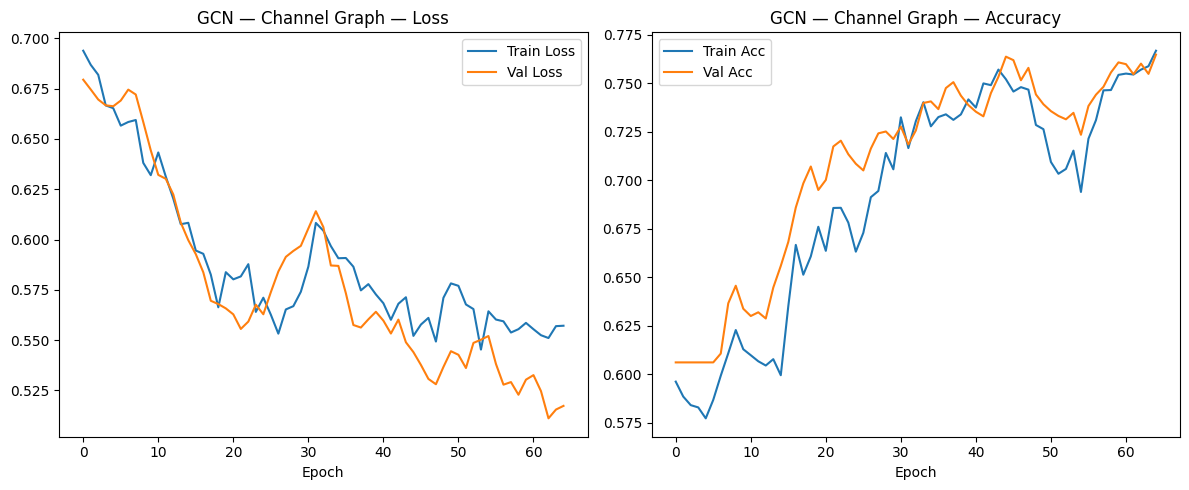

In [37]:
# --- GCN on Channel Graph ---
gcn_ch_model     = GCN(in_channels=IN_CH).to(device)
gcn_ch_optimizer = torch.optim.Adam(gcn_ch_model.parameters(), lr=1e-3, weight_decay=1e-4)
gcn_ch_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gcn_ch_optimizer, patience=10, factor=0.5)

gcn_ch_history = run_gnn_training(
    gcn_ch_model, ch_train_loader, ch_val_loader,
    gcn_ch_optimizer, gcn_ch_scheduler, criterion,
    n_epochs=200, model_name="GCN-Channel"
)
plot_history(gcn_ch_history, title="GCN — Channel Graph")

## GAT on Channel Graph

[GAT-Channel] Epoch 001 | Train Loss 0.6590 | Val Loss 0.6771 | Val Acc 0.606 | LR 0.001000 ← best
[GAT-Channel] Epoch 002 | Train Loss 0.6331 | Val Loss 0.6870 | Val Acc 0.606 | LR 0.001000
[GAT-Channel] Epoch 003 | Train Loss 0.6506 | Val Loss 0.6717 | Val Acc 0.606 | LR 0.001000
[GAT-Channel] Epoch 004 | Train Loss 0.6489 | Val Loss 0.7160 | Val Acc 0.606 | LR 0.001000
[GAT-Channel] Epoch 005 | Train Loss 0.6210 | Val Loss 0.6975 | Val Acc 0.606 | LR 0.001000
[GAT-Channel] Epoch 006 | Train Loss 0.6168 | Val Loss 0.6963 | Val Acc 0.606 | LR 0.001000
[GAT-Channel] Epoch 007 | Train Loss 0.5842 | Val Loss 0.7230 | Val Acc 0.727 | LR 0.001000 ← best
[GAT-Channel] Epoch 008 | Train Loss 0.6427 | Val Loss 0.6961 | Val Acc 0.773 | LR 0.001000 ← best
[GAT-Channel] Epoch 009 | Train Loss 0.6287 | Val Loss 0.7186 | Val Acc 0.409 | LR 0.001000
[GAT-Channel] Epoch 010 | Train Loss 0.5823 | Val Loss 0.6806 | Val Acc 0.636 | LR 0.001000
[GAT-Channel] Epoch 011 | Train Loss 0.6111 | Val Loss 0.67

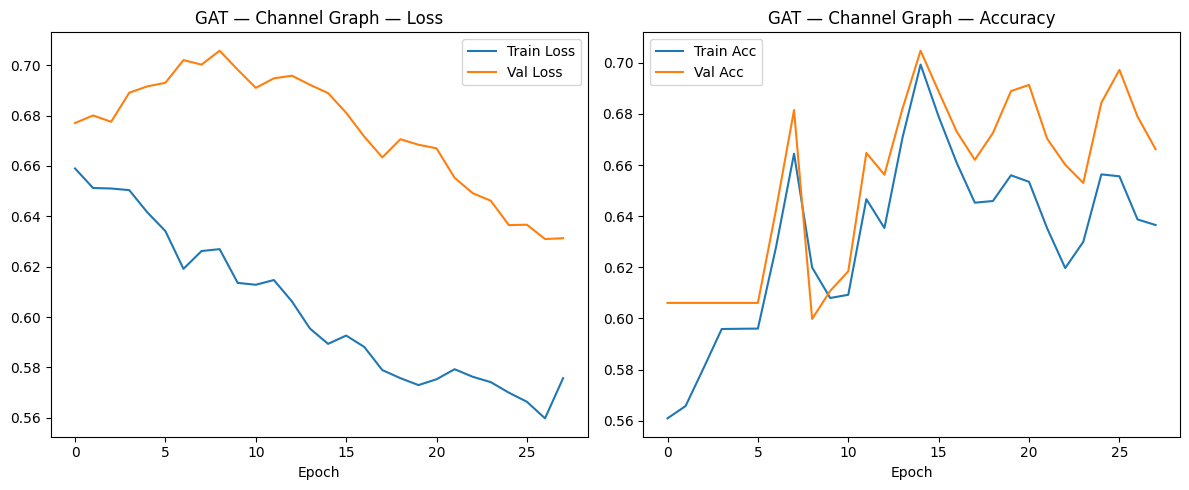

In [38]:
# --- GAT on Channel Graph ---
gat_ch_model     = GATClassifier(in_channels=IN_CH).to(device)
gat_ch_optimizer = torch.optim.Adam(gat_ch_model.parameters(), lr=1e-3, weight_decay=1e-4)
gat_ch_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gat_ch_optimizer, patience=10, factor=0.5)

gat_ch_history = run_gnn_training(
    gat_ch_model, ch_train_loader, ch_val_loader,
    gat_ch_optimizer, gat_ch_scheduler, criterion,
    n_epochs=200, model_name="GAT-Channel"
)
plot_history(gat_ch_history, title="GAT — Channel Graph")

# 10. EXPERIMENT 2 — Hetero Graph

In [39]:
# ============================================================
# 10. EXPERIMENT 2 — Hetero Graph
# ============================================================

train_ht, val_ht, test_ht = stratified_split(hetero_graphs)

ht_train_loader = make_weighted_loader(train_ht, batch_size=16)
ht_val_loader   = GeoDataLoader(val_ht,  batch_size=16)
ht_test_loader  = GeoDataLoader(test_ht, batch_size=16)

print("Hetero Graph splits:")
print("  Train:", Counter(g.y.item() for g in train_ht))
print("  Val:  ", Counter(g.y.item() for g in val_ht))
print("  Test: ", Counter(g.y.item() for g in test_ht))

IN_HT = hetero_graphs[0].x.size(1)

Hetero Graph splits:
  Train: Counter({0: 183, 1: 129})
  Val:   Counter({0: 39, 1: 27})
  Test:  Counter({0: 40, 1: 29})


## RGCN on Hetero Graph

[RGCN-Hetero] Epoch 001 | Train Loss 0.6297 | Val Loss 0.5640 | Val Acc 0.758 | LR 0.001000 ← best
[RGCN-Hetero] Epoch 002 | Train Loss 0.5546 | Val Loss 0.4969 | Val Acc 0.758 | LR 0.001000
[RGCN-Hetero] Epoch 003 | Train Loss 0.5192 | Val Loss 0.5101 | Val Acc 0.758 | LR 0.001000
[RGCN-Hetero] Epoch 004 | Train Loss 0.5054 | Val Loss 0.5285 | Val Acc 0.742 | LR 0.001000
[RGCN-Hetero] Epoch 005 | Train Loss 0.5032 | Val Loss 0.4986 | Val Acc 0.758 | LR 0.001000
[RGCN-Hetero] Epoch 006 | Train Loss 0.4942 | Val Loss 0.4946 | Val Acc 0.788 | LR 0.001000 ← best
[RGCN-Hetero] Epoch 007 | Train Loss 0.5096 | Val Loss 0.4921 | Val Acc 0.758 | LR 0.001000
[RGCN-Hetero] Epoch 008 | Train Loss 0.5255 | Val Loss 0.4965 | Val Acc 0.773 | LR 0.001000
[RGCN-Hetero] Epoch 009 | Train Loss 0.4809 | Val Loss 0.5094 | Val Acc 0.773 | LR 0.001000
[RGCN-Hetero] Epoch 010 | Train Loss 0.5015 | Val Loss 0.4755 | Val Acc 0.788 | LR 0.001000
[RGCN-Hetero] Epoch 011 | Train Loss 0.5173 | Val Loss 0.4422 | Va

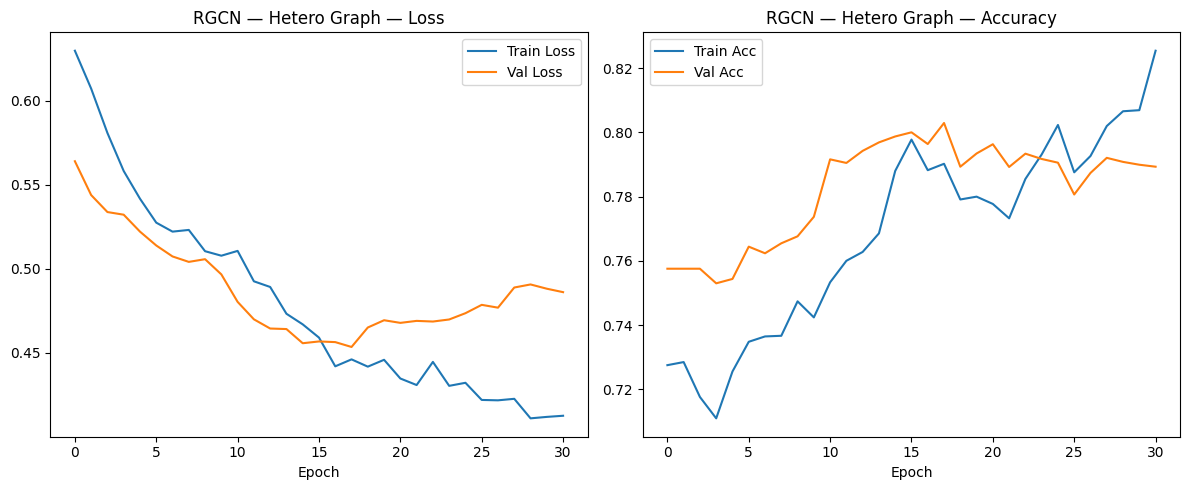

In [40]:
# --- RGCN on Hetero Graph ---
rgcn_ht_model     = HeteroGNN(in_channels=IN_HT).to(device)
rgcn_ht_optimizer = torch.optim.Adam(rgcn_ht_model.parameters(), lr=1e-3, weight_decay=1e-4)
rgcn_ht_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(rgcn_ht_optimizer, patience=10, factor=0.5)

rgcn_ht_history = run_gnn_training(
    rgcn_ht_model, ht_train_loader, ht_val_loader,
    rgcn_ht_optimizer, rgcn_ht_scheduler, criterion,
    n_epochs=200, model_name="RGCN-Hetero"
)
plot_history(rgcn_ht_history, title="RGCN — Hetero Graph")


## GAT on Hetero Graph

[GAT-Hetero] Epoch 001 | Train Loss 0.6433 | Val Loss 0.6048 | Val Acc 0.652 | LR 0.001000 ← best
[GAT-Hetero] Epoch 002 | Train Loss 0.6023 | Val Loss 0.5305 | Val Acc 0.727 | LR 0.001000 ← best
[GAT-Hetero] Epoch 003 | Train Loss 0.5944 | Val Loss 0.5368 | Val Acc 0.803 | LR 0.001000 ← best
[GAT-Hetero] Epoch 004 | Train Loss 0.5794 | Val Loss 0.5043 | Val Acc 0.788 | LR 0.001000
[GAT-Hetero] Epoch 005 | Train Loss 0.4950 | Val Loss 0.4913 | Val Acc 0.833 | LR 0.001000 ← best
[GAT-Hetero] Epoch 006 | Train Loss 0.5646 | Val Loss 0.4479 | Val Acc 0.818 | LR 0.001000
[GAT-Hetero] Epoch 007 | Train Loss 0.5321 | Val Loss 0.4512 | Val Acc 0.803 | LR 0.001000
[GAT-Hetero] Epoch 008 | Train Loss 0.4827 | Val Loss 0.4811 | Val Acc 0.803 | LR 0.001000
[GAT-Hetero] Epoch 009 | Train Loss 0.4757 | Val Loss 0.4578 | Val Acc 0.803 | LR 0.001000
[GAT-Hetero] Epoch 010 | Train Loss 0.4518 | Val Loss 0.4590 | Val Acc 0.803 | LR 0.001000
[GAT-Hetero] Epoch 011 | Train Loss 0.4826 | Val Loss 0.4001 |

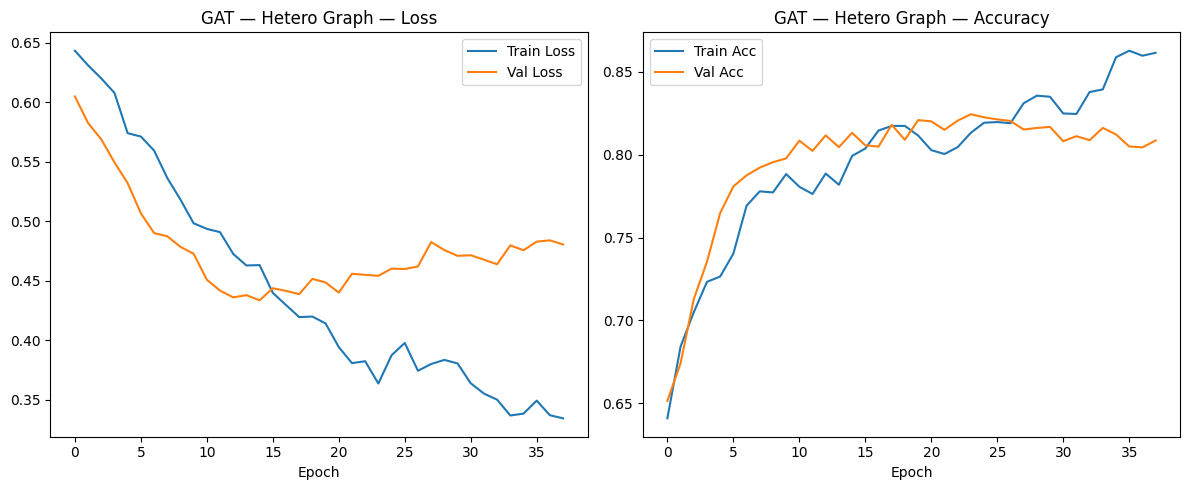

In [50]:
# --- GAT on Hetero Graph ---
gat_ht_model     = GATClassifier(in_channels=IN_HT, dropout=0.5).to(device)
gat_ht_optimizer = torch.optim.Adam(gat_ht_model.parameters(), lr=1e-3, weight_decay=1e-4)
gat_ht_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gat_ht_optimizer, patience=10, factor=0.5)

gat_ht_history = run_gnn_training(
    gat_ht_model, ht_train_loader, ht_val_loader,
    gat_ht_optimizer, gat_ht_scheduler, criterion,
    n_epochs=100, model_name="GAT-Hetero"
)
plot_history(gat_ht_history, title="GAT — Hetero Graph")

# 11. EXPERIMENT 3 — LSTM BASELINE

LSTM splits:
  Train: Counter({0: 183, 1: 129})
  Val:   Counter({0: 39, 1: 28})
  Test:  Counter({0: 40, 1: 28})
[LSTM] Epoch 001 | Train Loss 0.6927 | Val Loss 0.6888 | Val Acc 0.522 | LR 0.001000
[LSTM] Epoch 002 | Train Loss 0.6891 | Val Loss 0.6777 | Val Acc 0.537 | LR 0.001000
[LSTM] Epoch 003 | Train Loss 0.6802 | Val Loss 0.6593 | Val Acc 0.522 | LR 0.001000
[LSTM] Epoch 004 | Train Loss 0.6803 | Val Loss 0.6655 | Val Acc 0.567 | LR 0.001000
[LSTM] Epoch 005 | Train Loss 0.6552 | Val Loss 0.6772 | Val Acc 0.582 | LR 0.001000
[LSTM] Epoch 006 | Train Loss 0.6499 | Val Loss 0.6796 | Val Acc 0.597 | LR 0.001000
[LSTM] Epoch 007 | Train Loss 0.6483 | Val Loss 0.6945 | Val Acc 0.463 | LR 0.001000
[LSTM] Epoch 008 | Train Loss 0.6321 | Val Loss 0.6758 | Val Acc 0.567 | LR 0.001000
[LSTM] Epoch 009 | Train Loss 0.6191 | Val Loss 0.6849 | Val Acc 0.552 | LR 0.001000
[LSTM] Epoch 010 | Train Loss 0.6120 | Val Loss 0.7420 | Val Acc 0.552 | LR 0.001000
[LSTM] Epoch 011 | Train Loss 0.5886

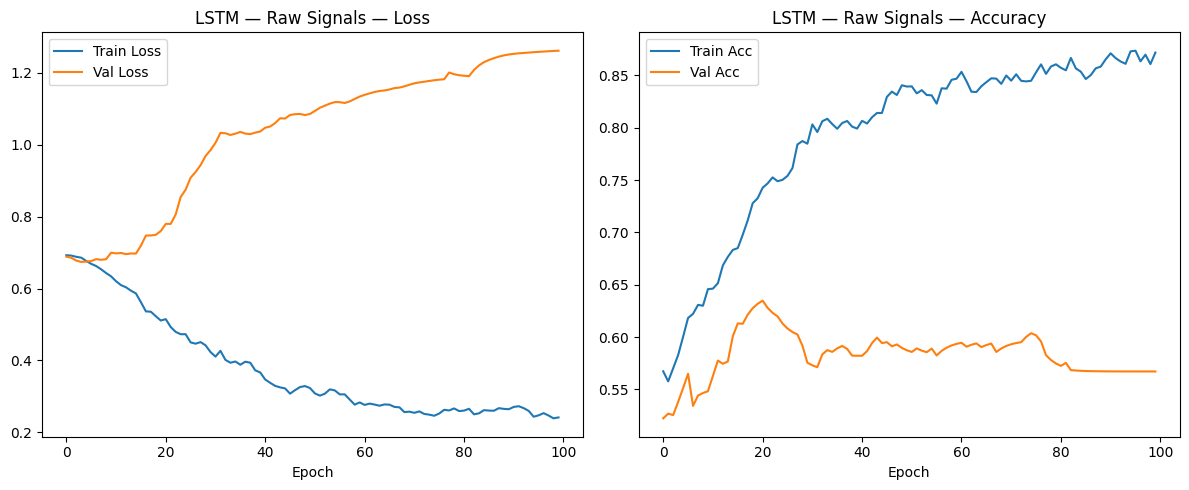

In [42]:
# ============================================================
# 11. EXPERIMENT 3 — LSTM BASELINE
# ============================================================

class HyperWindowDataset(Dataset):
    def __init__(self, df):
        self.X = df["signals"].values
        self.y = df["label"].values

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx].T, dtype=torch.float)  # (time, channels)
        y = torch.tensor(self.y[idx],   dtype=torch.long)
        return x, y


# Stratified split for LSTM (hyper_df level)
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    hyper_df.index, test_size=0.3, stratify=hyper_df["label"], random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=hyper_df.loc[temp_idx, "label"], random_state=42
)

lstm_train_df = hyper_df.loc[train_idx]
lstm_val_df   = hyper_df.loc[val_idx]
lstm_test_df  = hyper_df.loc[test_idx]

# Weighted sampler for LSTM train loader
lstm_labels  = lstm_train_df["label"].values
lstm_counts  = Counter(lstm_labels)
lstm_weights = [1.0 / lstm_counts[l] for l in lstm_labels]
lstm_sampler = WeightedRandomSampler(lstm_weights, num_samples=len(lstm_weights), replacement=True)

lstm_train_loader = DataLoader(HyperWindowDataset(lstm_train_df), batch_size=16, sampler=lstm_sampler)
lstm_val_loader   = DataLoader(HyperWindowDataset(lstm_val_df),   batch_size=16)
lstm_test_loader  = DataLoader(HyperWindowDataset(lstm_test_df),  batch_size=16)

print("LSTM splits:")
print("  Train:", Counter(lstm_train_df["label"]))
print("  Val:  ", Counter(lstm_val_df["label"]))
print("  Test: ", Counter(lstm_test_df["label"]))

lstm_model     = LSTMClassifier(n_channels=7, hidden_dim=64).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, patience=10, factor=0.5)

lstm_history = run_lstm_training(
    lstm_model, lstm_train_loader, lstm_val_loader,
    lstm_optimizer, lstm_scheduler, criterion,
    n_epochs=100, model_name="LSTM"
)
plot_history(lstm_history, title="LSTM — Raw Signals")

# 12. FINAL COMPARISON

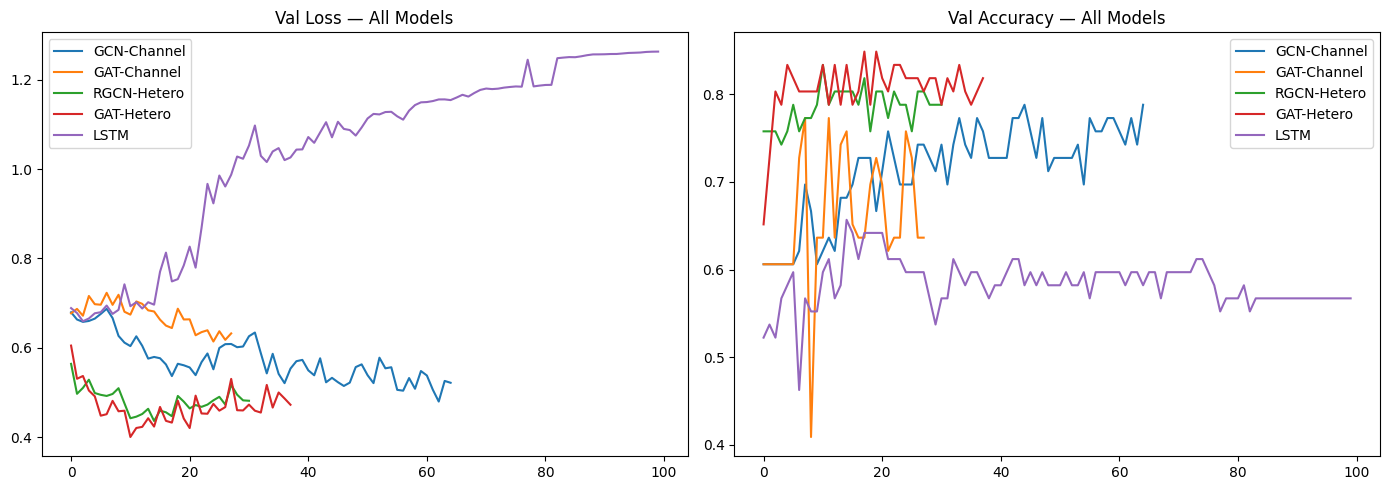


=== Best Val Accuracy ===
  GCN-Channel    : 0.7879
  GAT-Channel    : 0.7727
  RGCN-Hetero    : 0.8333
  GAT-Hetero     : 0.8485
  LSTM           : 0.6567


In [51]:
# ============================================================
# 12. FINAL COMPARISON
# ============================================================

all_results = {
    "GCN-Channel":  gcn_ch_history,
    "GAT-Channel":  gat_ch_history,
    "RGCN-Hetero":  rgcn_ht_history,
    "GAT-Hetero":   gat_ht_history,
    "LSTM":         lstm_history,
}

plot_comparison(all_results)

# Print best val accuracy per model
print("\n=== Best Val Accuracy ===")
for name, h in all_results.items():
    print(f"  {name:<15}: {max(h['val_acc']):.4f}")

## Comparison Visualisation

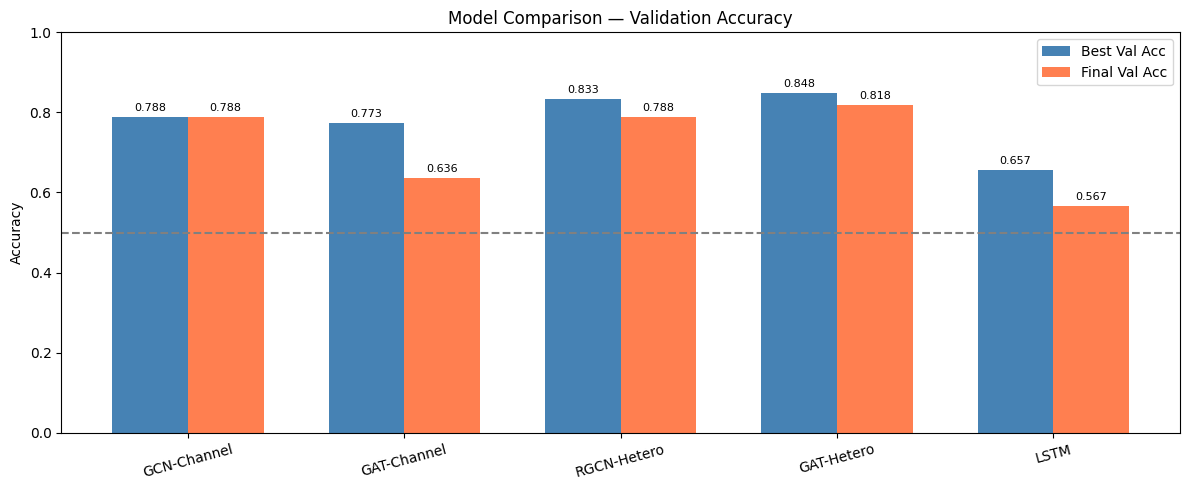

In [52]:
# ============================================================
# VIZ 11: Final model comparison — summary bar chart
# ============================================================
model_names = list(all_results.keys())
best_val_accs = [max(h["val_acc"]) for h in all_results.values()]
final_val_accs = [h["val_acc"][-1] for h in all_results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, best_val_accs,  width, label="Best Val Acc",  color="steelblue")
bars2 = ax.bar(x + width/2, final_val_accs, width, label="Final Val Acc", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Model Comparison — Validation Accuracy")
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", label="Chance level")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# TEST Evaluation:

In [53]:
def evaluate_test(model, loader, criterion, model_name="", is_lstm=False):
    if is_lstm:
        loss, acc = eval_lstm_with_loss(model, loader, criterion)
    else:
        loss, acc = eval_with_loss(model, loader, criterion)
    print(f"[{model_name}] TEST Loss: {loss:.4f} | TEST Acc: {acc:.4f}")
    return acc

print("\n=== FINAL TEST SET RESULTS ===")
evaluate_test(gcn_ch_model,  ch_test_loader,   criterion, "GCN-Channel")
evaluate_test(gat_ch_model,  ch_test_loader,   criterion, "GAT-Channel")
evaluate_test(rgcn_ht_model, ht_test_loader,   criterion, "RGCN-Hetero")
evaluate_test(gat_ht_model,  ht_test_loader,   criterion, "GAT-Hetero")
evaluate_test(lstm_model,    lstm_test_loader,  criterion, "LSTM", is_lstm=True)


=== FINAL TEST SET RESULTS ===
[GCN-Channel] TEST Loss: 0.5063 | TEST Acc: 0.8116
[GAT-Channel] TEST Loss: 0.6311 | TEST Acc: 0.7391
[RGCN-Hetero] TEST Loss: 0.4065 | TEST Acc: 0.8261
[GAT-Hetero] TEST Loss: 0.3694 | TEST Acc: 0.8261
[LSTM] TEST Loss: 0.9795 | TEST Acc: 0.6324


0.6323529411764706

## Metrics utilities

In [54]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report
)

@torch.no_grad()
def get_predictions(model, loader, is_lstm=False):
    """Returns true labels, predicted labels, and probabilities."""
    model.eval()
    all_labels = []
    all_preds  = []
    all_probs  = []

    for batch in loader:
        if is_lstm:
            x, y = batch
            x, y = x.to(device), y.to(device)
            out  = model(x)
        else:
            batch = batch.to(device)
            out   = model(batch)
            y     = batch.y

        probs = torch.softmax(out, dim=1)[:, 1]   # prob of class 1
        preds = out.argmax(dim=1)

        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

## Confusion Matrix

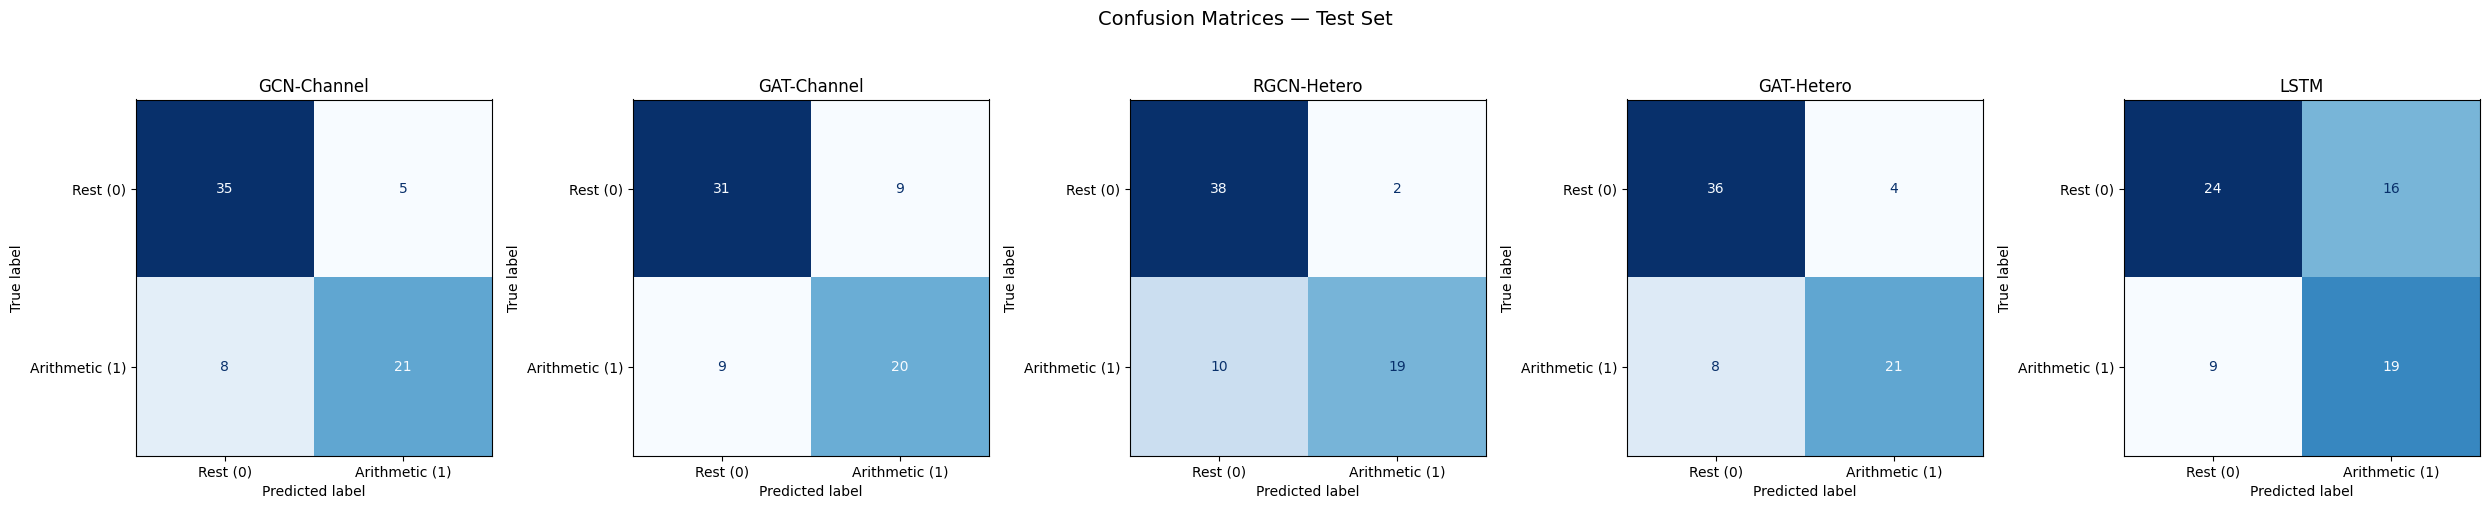

In [55]:
def plot_confusion_matrices(models_dict):
    """
    models_dict = {
        "GCN-Channel":  (gcn_ch_model,  ch_test_loader,  False),
        "GAT-Hetero":   (gat_ht_model,  ht_test_loader,  False),
        "LSTM":         (lstm_model,     lstm_test_loader, True),
    }
    """
    n = len(models_dict)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, (model, loader, is_lstm)) in zip(axes, models_dict.items()):
        labels, preds, _ = get_predictions(model, loader, is_lstm)
        cm = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Rest (0)", "Arithmetic (1)"]
        )
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=12)

    plt.suptitle("Confusion Matrices — Test Set", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


models_for_eval = {
    "GCN-Channel":  (gcn_ch_model,  ch_test_loader,  False),
    "GAT-Channel":  (gat_ch_model,  ch_test_loader,  False),
    "RGCN-Hetero":  (rgcn_ht_model, ht_test_loader,  False),
    "GAT-Hetero":   (gat_ht_model,  ht_test_loader,  False),
    "LSTM":         (lstm_model,    lstm_test_loader, True),
}

plot_confusion_matrices(models_for_eval)

## ROC Curves

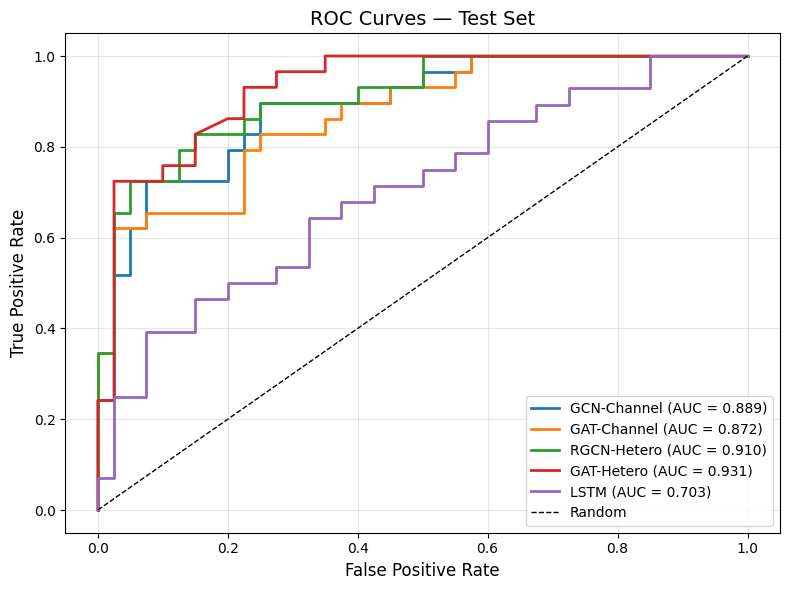

In [56]:
def plot_roc_curves(models_dict):
    plt.figure(figsize=(8, 6))

    for name, (model, loader, is_lstm) in models_dict.items():
        labels, _, probs = get_predictions(model, loader, is_lstm)
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

    plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("ROC Curves — Test Set", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(models_for_eval)

## Percision-Recall Curves

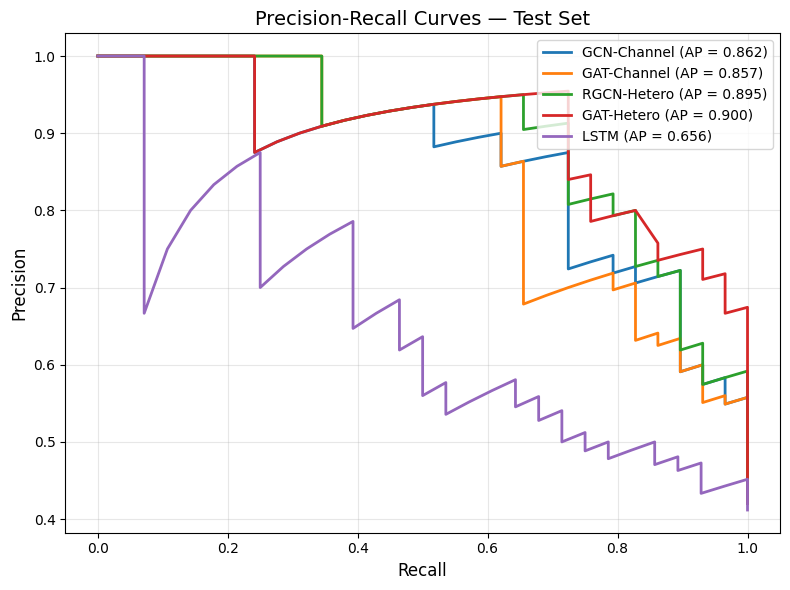

In [57]:
def plot_precision_recall_curves(models_dict):
    plt.figure(figsize=(8, 6))

    for name, (model, loader, is_lstm) in models_dict.items():
        labels, _, probs = get_predictions(model, loader, is_lstm)
        precision, recall, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", linewidth=2)

    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision-Recall Curves — Test Set", fontsize=14)
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_precision_recall_curves(models_for_eval)

## Full classification report

In [58]:
def print_classification_reports(models_dict):
    for name, (model, loader, is_lstm) in models_dict.items():
        labels, preds, _ = get_predictions(model, loader, is_lstm)
        print(f"\n{'='*50}")
        print(f"  {name}")
        print(f"{'='*50}")
        print(classification_report(
            labels, preds,
            target_names=["Rest (0)", "Arithmetic (1)"]
        ))

print_classification_reports(models_for_eval)


  GCN-Channel
                precision    recall  f1-score   support

      Rest (0)       0.81      0.88      0.84        40
Arithmetic (1)       0.81      0.72      0.76        29

      accuracy                           0.81        69
     macro avg       0.81      0.80      0.80        69
  weighted avg       0.81      0.81      0.81        69


  GAT-Channel
                precision    recall  f1-score   support

      Rest (0)       0.78      0.78      0.78        40
Arithmetic (1)       0.69      0.69      0.69        29

      accuracy                           0.74        69
     macro avg       0.73      0.73      0.73        69
  weighted avg       0.74      0.74      0.74        69


  RGCN-Hetero
                precision    recall  f1-score   support

      Rest (0)       0.79      0.95      0.86        40
Arithmetic (1)       0.90      0.66      0.76        29

      accuracy                           0.83        69
     macro avg       0.85      0.80      0.81      

## Demographic Fairness

In [59]:
# Check if EDF files contain patient info
import pyedflib

sample_edf = list(Path(edf_path).glob("*.edf"))[0]
with pyedflib.EdfReader(str(sample_edf)) as f:
    print("Patient name:    ", f.getPatientName())
    print("Patient code:    ", f.getPatientCode())
    print("Patient gender:  ", f.getGender())
    print("Patient birthdate:", f.getBirthdate())
    print("Admin code:      ", f.getAdmincode())
    print("Recording date:  ", f.getStartdatetime())

Patient name:     Subject10
Patient code:     2
Patient gender:   Male
Patient birthdate: 01 jan 1993
Admin code:       2
Recording date:   2010-01-01 00:00:00


/tmp/ipython-input-1091799788.py:8: DeprecationWarning: Method 'getGender' is deprecated, use 'getSex' instead.
  print("Patient gender:  ", f.getGender())


### Get metadata of all EDF files

In [60]:
import pyedflib
from datetime import datetime

def extract_edf_metadata(base_path):
    """Extract subject demographics from all EDF files."""
    metadata = {}
    base_path = Path(base_path)

    for edf_file in base_path.glob("*.edf"):
        with pyedflib.EdfReader(str(edf_file)) as f:
            name      = f.getPatientName()        # e.g. "Subject10"
            birthdate = f.getBirthdate()           # e.g. "01 jan 1993"
            sex       = f.getSex()                 # "Male" / "Female"
            rec_date  = f.getStartdatetime()       # datetime object

            # Calculate age at recording
            try:
                bd  = datetime.strptime(birthdate, "%d %b %Y")
                age = (rec_date - bd).days // 365
            except:
                age = None

            metadata[edf_file.name] = {
                "subject":   name,
                "sex":       sex,
                "birthdate": birthdate,
                "age":       age,
                "file":      edf_file.name
            }

    return metadata

edf_metadata = extract_edf_metadata(edf_path)

# Preview
meta_df = pd.DataFrame(edf_metadata).T
print(meta_df)
print("\nSex distribution:", Counter(meta_df["sex"]))
print("Age range:", meta_df["age"].min(), "—", meta_df["age"].max())

                   subject     sex    birthdate age             file
Subject10_1.edf  Subject10    Male  01 jan 1993  17  Subject10_1.edf
Subject01_2.edf   Subject1    Male  01 jan 1993  18  Subject01_2.edf
Subject13_2.edf  Subject13  Female  01 jan 1988  24  Subject13_2.edf
Subject11_2.edf  Subject11    Male  01 jan 1992  18  Subject11_2.edf
Subject00_1.edf   Subject0    Male  01 jan 1990  21  Subject00_1.edf
...                    ...     ...          ...  ..              ...
Subject05_2.edf   Subject5    Male  01 jan 1994  16  Subject05_2.edf
Subject07_1.edf   Subject7    Male  01 jan 1994  18  Subject07_1.edf
Subject09_2.edf   Subject9    Male  01 jan 1994  16  Subject09_2.edf
Subject09_1.edf   Subject9    Male  01 jan 1994  16  Subject09_1.edf
Subject08_1.edf   Subject8  Female  01 jan 1985  26  Subject08_1.edf

[72 rows x 5 columns]

Sex distribution: Counter({'Male': 53, 'Female': 19})
Age range: 16 — 26


### Link metadata to hyperdf:

In [69]:
# Step 2: Build metadata — only run this ONCE
sample_meta_list = []
for sample_id, s in enumerate(dataset):
    if s["source"] == "EDF":
        meta = edf_metadata.get(s["file"], {})
        sample_meta_list.append({
            "sample_id": sample_id,
            "sex":       meta.get("sex",  "Unknown"),
            "age":       meta.get("age",  None),
        })
    else:
        sample_meta_list.append({
            "sample_id": sample_id,
            "sex":       "Unknown",
            "age":       None,
        })

sample_meta_df = pd.DataFrame(sample_meta_list)

# Step 3: Merge — source column excluded to avoid collision
hyper_df = hyper_df.merge(sample_meta_df, on="sample_id", how="left")

# Step 4: Add age cohort
def assign_age_cohort(age):
    if age is None or np.isnan(age):
        return "Unknown"
    elif age < 25:
        return "Young (<25)"
    elif age < 35:
        return "Mid (25-34)"
    else:
        return "Senior (35+)"

hyper_df["age_cohort"] = hyper_df["age"].apply(assign_age_cohort)

# Step 5: Verify
print(hyper_df[["hyper_id", "label", "sex", "age", "age_cohort", "source"]].head(10))
print("\nSex counts:",        Counter(hyper_df["sex"]))
print("Age cohort counts:",   Counter(hyper_df["age_cohort"]))
print("Age stats:\n",         hyper_df["age"].describe())

   hyper_id  label     sex   age   age_cohort source
0         0      0    Male  17.0  Young (<25)    EDF
1         1      0    Male  17.0  Young (<25)    EDF
2         2      0    Male  17.0  Young (<25)    EDF
3         3      0    Male  17.0  Young (<25)    EDF
4         4      0    Male  17.0  Young (<25)    EDF
5         5      0    Male  17.0  Young (<25)    EDF
6         6      1    Male  18.0  Young (<25)    EDF
7         7      1    Male  18.0  Young (<25)    EDF
8         8      1  Female  24.0  Young (<25)    EDF
9         9      1  Female  24.0  Young (<25)    EDF

Sex counts: Counter({'Male': 209, 'Unknown': 164, 'Female': 74})
Age cohort counts: Counter({'Young (<25)': 275, 'Unknown': 164, 'Mid (25-34)': 8})
Age stats:
 count    283.000000
mean      18.243816
std        2.158750
min       16.000000
25%       17.000000
50%       17.000000
75%       19.000000
max       26.000000
Name: age, dtype: float64


### Fairness evaluation function

In [78]:
def fairness_evaluation(model, all_graphs, hyper_df, subgroup_col,
                         model_name="Model", is_lstm=False):
    groups        = hyper_df[subgroup_col].values
    unique_groups = [g for g in sorted(set(groups))
                     if g not in ("Unknown", None)]  # ← skip Unknown

    n    = len(unique_groups)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    print(f"\n{'='*60}")
    print(f"  Fairness Analysis — {model_name} — by {subgroup_col}")
    print(f"  Note: 'Unknown' subjects (TXT dataset) excluded — n={sum(groups=='Unknown')}")
    print(f"{'='*60}")

    group_accs = {}

    for ax, group in zip(axes, unique_groups):
        indices      = [i for i, g in enumerate(groups) if g == group]
        group_graphs = [all_graphs[i] for i in indices]

        if len(group_graphs) == 0:
            continue

        loader = GeoDataLoader(group_graphs, batch_size=16)
        labels, preds, probs = get_predictions(model, loader, is_lstm=False)

        acc  = (labels == preds).mean()
        group_accs[group] = acc

        cm   = confusion_matrix(labels, preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Rest", "Arithmetic"]
        )
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{group}\n(n={len(indices)}, acc={acc:.3f})", fontsize=11)

        print(f"\n{group} (n={len(indices)}):")
        print(classification_report(
            labels, preds,
            target_names=["Rest", "Arithmetic"],
            zero_division=0
        ))

    # Accuracy gap between Male and Female
    if len(group_accs) >= 2:
        vals = list(group_accs.values())
        keys = list(group_accs.keys())
        gap  = max(vals) - min(vals)
        print(f"\nAccuracy gap (Male vs Female): {gap:.4f}")
        print(f"  Best:  {keys[np.argmax(vals)]} ({max(vals):.4f})")
        print(f"  Worst: {keys[np.argmin(vals)]} ({min(vals):.4f})")

    plt.suptitle(f"Fairness: {model_name} by {subgroup_col}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return group_accs

### Run fairness analysis for two best models


=== RGCN-Hetero Fairness by Sex ===

  Fairness Analysis — RGCN-Hetero — by sex
  Note: 'Unknown' subjects (TXT dataset) excluded — n=164

Female (n=74):
              precision    recall  f1-score   support

        Rest       0.76      0.98      0.85        54
  Arithmetic       0.75      0.15      0.25        20

    accuracy                           0.76        74
   macro avg       0.75      0.57      0.55        74
weighted avg       0.76      0.76      0.69        74


Male (n=209):
              precision    recall  f1-score   support

        Rest       0.80      0.94      0.86       157
  Arithmetic       0.60      0.29      0.39        52

    accuracy                           0.78       209
   macro avg       0.70      0.61      0.63       209
weighted avg       0.75      0.78      0.74       209


Accuracy gap (Male vs Female): 0.0184
  Best:  Male (0.7751)
  Worst: Female (0.7568)


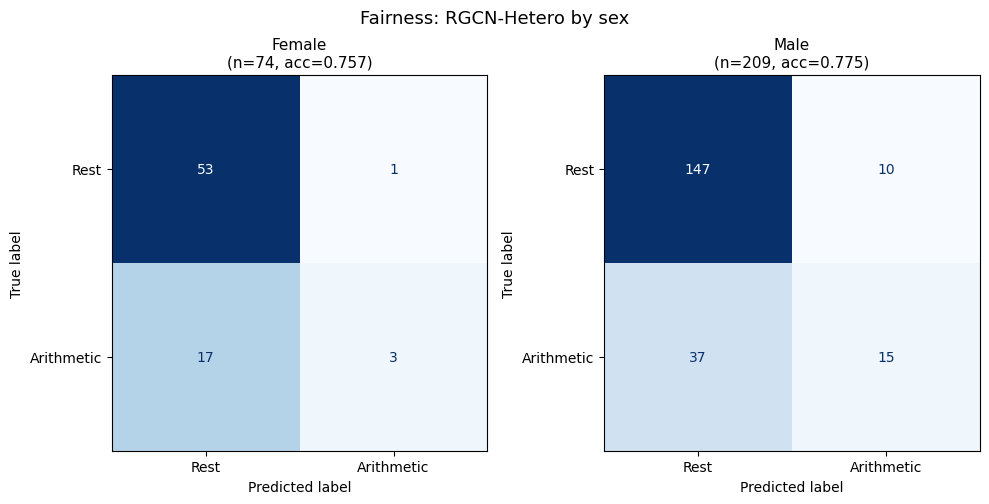


=== GAT-Hetero Fairness by Sex ===

  Fairness Analysis — GAT-Hetero — by sex
  Note: 'Unknown' subjects (TXT dataset) excluded — n=164

Female (n=74):
              precision    recall  f1-score   support

        Rest       0.79      0.91      0.84        54
  Arithmetic       0.58      0.35      0.44        20

    accuracy                           0.76        74
   macro avg       0.69      0.63      0.64        74
weighted avg       0.73      0.76      0.73        74


Male (n=209):
              precision    recall  f1-score   support

        Rest       0.85      0.90      0.87       157
  Arithmetic       0.63      0.52      0.57        52

    accuracy                           0.80       209
   macro avg       0.74      0.71      0.72       209
weighted avg       0.79      0.80      0.80       209


Accuracy gap (Male vs Female): 0.0471
  Best:  Male (0.8038)
  Worst: Female (0.7568)


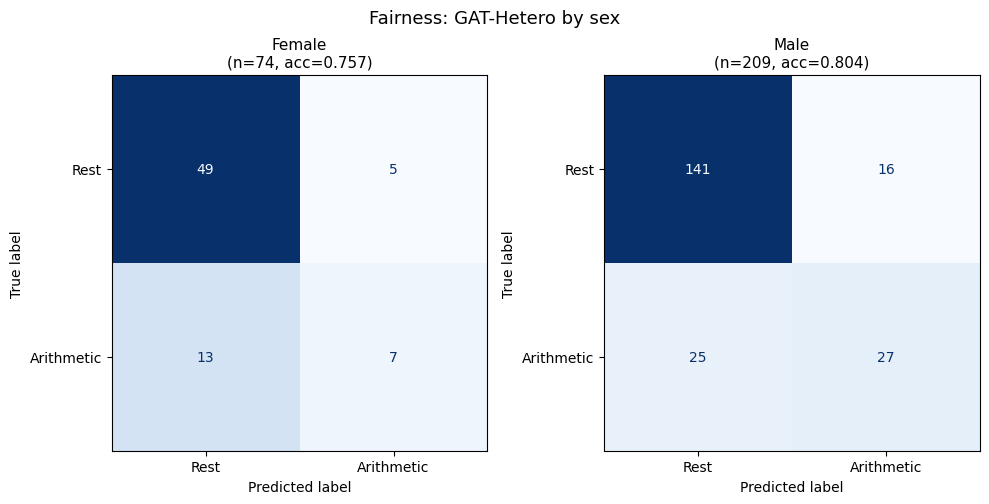

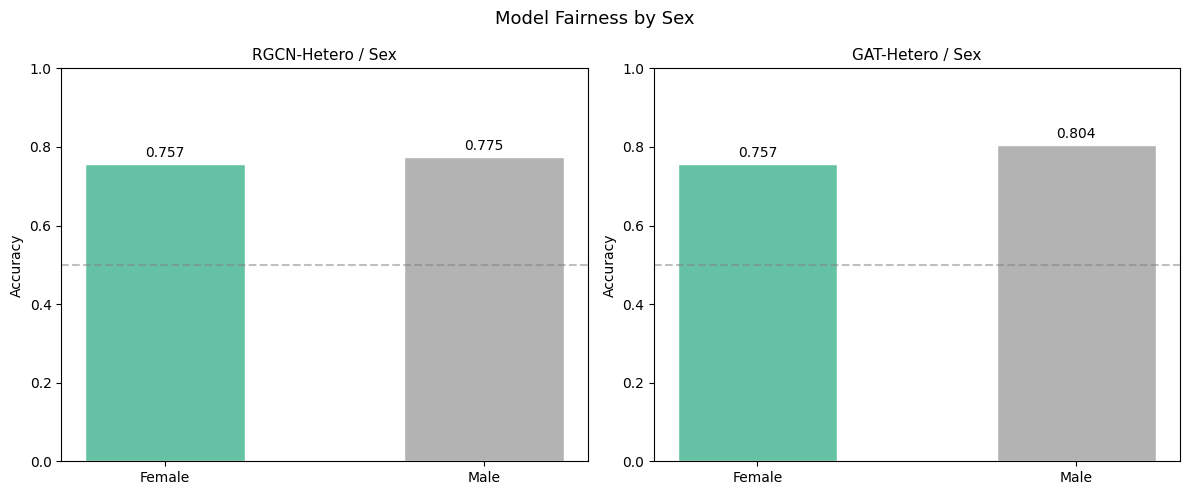

In [79]:
# ============================================================
# FAIRNESS ANALYSIS — Sex only
# ============================================================

print("\n=== RGCN-Hetero Fairness by Sex ===")
rgcn_sex_accs = fairness_evaluation(
    rgcn_ht_model, hetero_graphs, hyper_df,
    subgroup_col="sex",
    model_name="RGCN-Hetero"
)

print("\n=== GAT-Hetero Fairness by Sex ===")
gat_sex_accs = fairness_evaluation(
    gat_ht_model, hetero_graphs, hyper_df,
    subgroup_col="sex",
    model_name="GAT-Hetero"
)

# Summary chart
plot_fairness_summary({
    "RGCN-Hetero / Sex": rgcn_sex_accs,
    "GAT-Hetero / Sex":  gat_sex_accs,
}, title="Model Fairness by Sex")

### Summary fairness bar chart

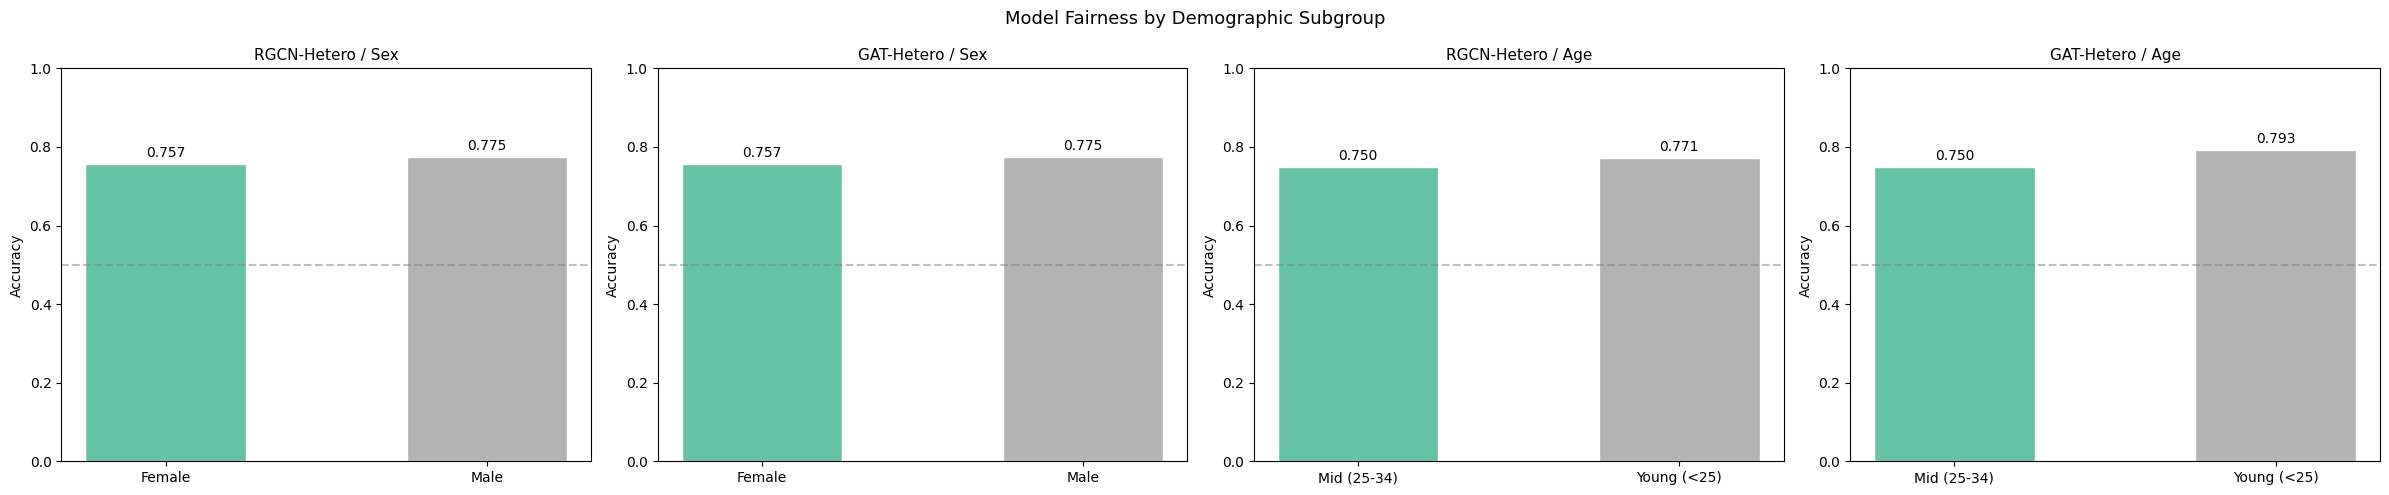

In [80]:
def plot_fairness_summary(results_dict, title="Fairness Summary"):
    """
    results_dict = {
        "RGCN-Hetero Sex":      {"Male": 0.82, "Female": 0.79},
        "GAT-Hetero Sex":       {"Male": 0.81, "Female": 0.80},
        "RGCN-Hetero Age":      {"Young": 0.83, "Mid": 0.80, "Senior": 0.78},
    }
    """
    fig, axes = plt.subplots(1, len(results_dict),
                             figsize=(6 * len(results_dict), 5))
    if len(results_dict) == 1:
        axes = [axes]

    for ax, (name, group_accs) in zip(axes, results_dict.items()):
        groups = list(group_accs.keys())
        accs   = list(group_accs.values())
        colors = plt.cm.Set2(np.linspace(0, 1, len(groups)))

        bars = ax.bar(groups, accs, color=colors, edgecolor="white", width=0.5)
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
        ax.set_title(name, fontsize=11)
        ax.set_ylabel("Accuracy")

        for bar, acc in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{acc:.3f}", ha="center", va="bottom", fontsize=10)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# Call after running fairness_evaluation
plot_fairness_summary({
    "RGCN-Hetero / Sex":      rgcn_sex_accs,
    "GAT-Hetero / Sex":       rgcn_sex_accs,   # replace with gat_sex_accs
    "RGCN-Hetero / Age":      rgcn_age_accs,
    "GAT-Hetero / Age":       gat_age_accs,
}, title="Model Fairness by Demographic Subgroup")